# Table of contents

* **Introduction**
* **Objective**
* **Pipeline Overview**
* **Data Dictionary**
* **Approach**
* **Setup Environments**
* **Data Loading**
* **Exploratory Data Analysis (EDA)**
* **Data Preprocessing**
* **Model Training**
    * TF-IDF Vectorization and Model Construction
    * Model Visualization and Diagnostics
    * Automated Hyperparameter Tuning (Optuna)
* **Model Evaluation**
    * ROUGE Score Evaluation
    * BLEU Score Evaluation
    * Evaluation Conclusion
* **Conclusion**
* **References**

# Introduction

Text summarization is a critical discipline in Natural Language Processing (NLP), focusing on condensing lengthy documents into concise, informative summaries while preserving essential meaning. Widespread applications exist across news aggregation, document categorization, search engines, and content curation. This demonstration details extractive text summarization utilizing the TF-IDF (Term Frequency-Inverse Document Frequency) technique, which is recognized for its classical foundation, computational efficiency, and interpretability. The BBC News Summary dataset is employed, featuring full news articles and corresponding human-written summaries across five categories: business, entertainment, politics, sport, and tech. The implementation covers a complete pipeline including data handling, TF-IDF modeling, extractive summary generation, visualization (word clouds, keyword-sentence networks), hyperparameter tuning with Optuna, and evaluation using ROUGE and BLEU metrics.

# Objective

The system's development targets the creation of an extractive text summarizer based on TF-IDF. The goals of this system are to:

- Accurately score and identify the most important sentences within a news article.
- Generate coherent and informative summaries.
- Allow for systematic evaluation using standard NLP metrics (ROUGE, BLEU).
- Provide insight into sentence importance via visualizations and network analysis.
- Achieve optimized performance through automated hyperparameter tuning.

# Pipeline Overview

The summarization pipeline follows a structured, sequential process. The key steps are:

- Load BBC News Dataset.
- Perform Data Preprocessing and Cleaning.
- Apply TF-IDF Vectorization.
- Conduct Sentence Scoring and Ranking.
- Extract Top Sentences.
- Generate Final Summary.
- Evaluate performance with ROUGE/BLEU metrics.
- Visualize Results and Network graphs.

# Data Dictionary

    BBC News Summary (Root Folder)/
                                    - News Articles (Sub-folder: Full Text)/
                                    
                                         - business (Contains article_id.txt, e.g., 001.txt)
                                         - entertainment (Contains article_id.txt)
                                         - politics (Contains article_id.txt)
                                         - sport (Contains article_id.txt)
                                         - tech (Contains article_id.txt)
    
                                    - Summaries (Sub-folder: Summarized Versions)/
                                     
                                         - business (Contains summary_id.txt, e.g., 001.txt)
                                         - entertainment (Contains summary_id.txt)
                                         - politics (Contains summary_id.txt)
                                         - sport (Contains summary_id.txt)
                                         - tech (Contains summary_id.txt)

[Dataset Link](https://www.kaggle.com/datasets/pariza/bbc-news-summary/data)

# Approach

**Type of Text Summarization**

- Extractive: Take up a document and extract important sentences from it as it is i.e. without changing any word. Hence, if the document has 80 sentences, the Extractive method will pick up 5–6 sentences (depending on the user how long a summary he wants) from this lot of 80 sentences without any change. It can be taken as selecting some sentences on the basis of their importance in the document
- Abstractive: Creating a summary from a document depending on the semantics of the document and not exact sentences. Hence, a summary generated this way may have sentences not even used in the document but with the same semantics.

In this project, it is Extractive text summarization.

**Preprocess Pipeline Approach**

The preprocessing pipeline ensures the data is structured and clean for model consumption.

- Dataset Structure: The BBC News Summary dataset is organized such that each .txt article file in the `News Articles/category/` directory has a paired reference summary in the `Summaries/category/` directory, sharing the same filename.
- Loading and Pivoting: Directory traversal functions are used to locate and load article and summary text. The collected data is pivoted to establish an alignment between articles and their respective summaries by filename and category. The resulting structured data includes columns for filename, category, News Articles, and Summaries.
- Sampling and Splitting: A small fraction of the total data is selected (e.g., $1%$, fixed state) to facilitate faster prototyping. The sampled data is then split into an $80%$ training portion and a $20%$ test portion for development and evaluation purposes.
- Text Cleaning: A custom function is applied to both the news articles and the summaries. The process includes conversion to lowercase, removal of punctuation and numerical digits, normalization of whitespace, and filtration of common English stopwords. The resulting output is a clean string composed of words longer than one character.

**Model Training Approach**

The TF-IDF technique is used to create a quantitative representation of the text, followed by sentence scoring.

- TF-IDF Vectorization: The `TfidfVectorizer` is initialized with specific constraints on the size and frequency of terms. Vocabulary size is limited (`max_features`), terms appearing too infrequently are ignored (`min_df`), and overly common terms are filtered out (`max_df`). The vectorizer is configured to capture both unigrams and bigrams (`ngram_range = (1, 2)`). The training article text is used to fit the vectorizer, and the training text is transformed into a TF-IDF matrix.
- Custom Summarizer Class: A dedicated class handles the extractive summarization process. Within the summarization method, the input article is segmented into sentences. These sentences are cleaned before being transformed into a TF-IDF matrix using the pre-fitted vectorizer. Sentence scoring is calculated by summing the TF-IDF scores of all words within that sentence. The sentences are ranked based on their total scores, and the indices corresponding to the top-k sentences (specified by `num_sentences`) are selected. To maintain reading coherence, the chosen sentences are re-sorted according to their original position in the article before being joined into the final summary string.
- Hyperparameter Tuning (Optuna): An automated framework, Optuna, is used to optimize the crucial parameters of the summarizer system. Optimized parameters include `max_features, min_df, max_df, ngram_range` of the vectorizer, and the final extracted sentence count (`num_sentences`). The tuning process seeks to maximize a chosen BLEU metric.

**Model Evaluation Approach**

The system's performance is assessed using industry-standard metrics, and its parameters are optimized.

- ROUGE (Recall-Oriented Understudy for Gisting Evaluation): This metric is utilized to quantify the word and phrase overlap between the generated summary and the human-written reference summary. The specific variants employed include ROUGE-1, ROUGE-2, and ROUGE-Lsum.
- BLEU (Bilingual Evaluation Understudy): This metric evaluates n-gram precision and applies a penalty for brevity. While primarily designed for machine translation, the metric is included for a broader perspective on n-gram match quality.

# Setup Environments

**Packages Installation**

In [ ]:
%%capture
!pip install rouge_score
# !pip install wordcloud
# !pip install graphviz networkx matplotlib
# !pip install optuna # Optuna is a new dependency

**Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import re
import string
import os
from pathlib import Path
from collections import Counter
from itertools import product

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
import sklearn

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud, STOPWORDS

from rouge_score import rouge_scorer
from nltk.translate.bleu_score import corpus_bleu

import networkx as nx
from graphviz import Digraph

import optuna


try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    print("NLTK 'stopwords' corpus not found. Downloading...")
    nltk.download('stopwords')
    print("NLTK 'stopwords' corpus downloaded.")

try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    print("NLTK 'punkt' tokenizer not found. Downloading...")
    nltk.download('punkt')
    print("NLTK 'punkt' tokenizer downloaded.")

STOPWORDS = set(stopwords.words('english'))

# Data Loading

This foundational phase is concerned with Corpus Management and the crucial data restructuring required to establish a one-to-one mapping between source articles and their reference summaries. The goal is to create a clean, aligned dataset suitable for subsequent Natural Language Generation (NLG) tasks, specifically text summarization.

**Hierarchical Traversal and Text Retrieval**

The code begins by implementing a systematic Hierarchical Traversal of the dataset's file structure, utilizing the `os.walk` function, a key tool for file system navigation. The dataset adheres to a standard organization: articles and summaries are nested within categorical subdirectories (e.g., 'business', 'sport'), which are, in turn, housed in parent directories ('News Articles' and 'Summaries').

The file path components are strategically parsed to extract two essential metadata points: the document type (Article or Summary) and the category. This metadata, paired with the unique file name, is used to collect the raw text content for every document. A critical aspect here is Robust File I/O, where a `try-except` block handles potential `UnicodeDecodeError` exceptions—an important measure in real-world data pipelines to prevent run-time failure due to malformed or unexpected text encodings.

**Data Alignment through Pivoting**

The raw data is initially in a long format, where a source article and its corresponding summary reside in separate rows, distinguished only by the `article_or_summary` column. The task of abstractive or extractive summarization requires that the source document and the ground-truth reference summary be in the same row.

This transformation is achieved via the Pivoting operation, a core concept in data wrangling. The unique combination of the filename and category fields serves as a composite index key to match the related text snippets. The document type values are promoted to new column headers, yielding the desired wide format where the 'News Articles' and 'Summaries' texts are adjacent. This process of normalization is absolutely fundamental, as it guarantees the integrity of the corpus, ensuring the model is trained against the correct human-written reference summary for every input article.

In [ ]:
def load_and_pivot_bbc_news_dataset(base_data_path='/kaggle/input/bbc-news-summary/BBC News Summary/'):
    """
    Loads BBC News Summary dataset, including text content, and pivots it
    to match articles with their summaries by filename and category.

    Args:
        base_data_path (str): The base directory where the dataset is located.

    Returns:
        pd.DataFrame: A DataFrame with 'filename', 'category', 'News Articles' text,
                      and 'Summaries' text.
    """
    all_data = []

    for root, dirs, files in os.walk(base_data_path):
        parts = Path(root).parts
        
        if len(parts) >= 2 and (parts[-2] == 'News Articles' or parts[-2] == 'Summaries'):
            article_type = parts[-2]
            category = parts[-1]

            for filename in files:
                full_path = os.path.join(root, filename)
                
                try:
                    with open(full_path, 'r', encoding='utf-8') as f:
                        content = f.read()
                except Exception as e:
                    print(f"Warning: Could not read file {full_path}. Error: {e}")
                    content = ""

                all_data.append({
                    "filename": filename,
                    "category": category,
                    "article_or_summary": article_type,
                    "text_content": content
                })

    df_raw = pd.DataFrame(all_data)

    df_pivoted = df_raw.pivot_table(
        index=['filename', 'category'],
        columns='article_or_summary',
        values='text_content',
        aggfunc='first'
    ).reset_index()

    df_pivoted.columns.name = None

    final_df = df_pivoted[['filename', 'category', 'News Articles', 'Summaries']]
    
    return final_df

df = load_and_pivot_bbc_news_dataset()
df

,filename,category,News Articles,Summaries
0,001.txt,business,Ad sales boost Time Warner profit\n\nQuarterly...,TimeWarner said fourth quarter sales rose 2% t...
1,001.txt,entertainment,Gallery unveils interactive tree\n\nA Christma...,"The messages will be ""unwrapped"" by sculptor R..."
2,001.txt,politics,Labour plans maternity pay rise\n\nMaternity p...,She said her party would boost maternity pay i...
3,001.txt,sport,Claxton hunting first major medal\n\nBritish h...,"For the first time, Claxton has only been prep..."
4,001.txt,tech,Ink helps drive democracy in Asia\n\nThe Kyrgy...,The other common type of ink in elections is i...
...,...,...,...,...
2220,509.txt,business,Euro firms miss out on optimism\n\nMore than 9...,"Possibly as a result, the worry about low-cost..."
2221,509.txt,sport,Melzer shocks Agassi in San Jose\n\nSecond see...,Second seed Andre Agassi suffered a comprehens...
2222,510.txt,business,Lacroix label bought by US firm\n\nLuxury good...,LVMH said the French designer's haute couture ...
2223,510.txt,sport,Mirza makes Indian tennis history\n\nTeenager ...,Teenager Sania Mirza completed a superb week a...


**Train and Test Data Split**

To manage computational constraints and facilitate rigorous model evaluation, the aligned corpus must undergo a two-step process: reduction and partitioning.

**Computational Constraint Management and Reproducibility**

For the practical purposes of rapid prototyping, debugging, and initial hyperparameter tuning, the full dataset undergoes Data Reduction via random sampling, intentionally halving the corpus size (a $50%$ fraction). This step directly addresses the challenge of Computational Constraint Management, allowing for faster iteration cycles on less powerful hardware or within limited timeframes.To ensure scientific rigor and transparency, a fixed Random Seed (`random_state=42`) is strictly employed. This practice of ensuring Reproducibility guarantees that the exact same subset of documents is selected across all executions of the pipeline, providing a stable basis for comparing the results of different modeling experiments.

**Model Generalization and Unbiased Evaluation**

The sampled data is then subjected to Data Segregation using the `train_test_split` function. The conceptual driver for this is Model Generalization, the principle that a model's performance must be evaluated on data it has never encountered during development.This is implemented using the Hold-out Cross-Validation strategy, partitioning the data into a training set ($80%$) and an isolated test set ($20%$). The larger Training Set is dedicated to model fitting, feature engineering, and learning the complex patterns between articles and summaries. The smaller, completely unseen Test Set serves as the final, objective benchmark. By keeping the test data separate, the derived performance metrics provide an unbiased quantification of the summarization system's effectiveness on novel inputs.

In [ ]:
df = df.sample(frac=0.5, random_state=42)

print(f"Sampled DataFrame shape (50%): {df.shape}")
print("\nHead of the 50% sampled DataFrame:")
df

Sampled DataFrame shape (50%): (1112, 4)

Head of the 50% sampled DataFrame:


,filename,category,News Articles,Summaries
414,083.txt,tech,Microsoft makes anti-piracy move\n\nMicrosoft ...,Microsoft releases regular security updates to...
420,085.txt,business,Home loan approvals rising again\n\nThe number...,"Mortgage lending rose by £7.1bn in December, u..."
1644,329.txt,tech,Intel unveils laser breakthrough\n\nIntel has ...,While work has been done to make some of the c...
416,084.txt,entertainment,Oscar nominees gear up for lunch\n\nLeonardo D...,Oscar nominees Swank and Foxx were among the w...
1232,247.txt,politics,Kennedy to make temple address\n\nCharles Kenn...,Mr Kennedy will also highlight the anger among...
...,...,...,...,...
1740,349.txt,business,S Korean lender faces liquidation\n\nCreditors...,"""Creditors would seek strong financial sanctio..."
1614,323.txt,tech,Blind student 'hears in colour'\n\nA blind stu...,Mr Wong has been blind from the age of seven a...
1281,257.txt,entertainment,Row threatens Hendrix museum plan\n\nProposals...,"Janie Hendrix, the guitarist's stepsister, sai..."
1905,382.txt,business,Ban on forced retirement under 65\n\nEmployers...,Trade and Industry Secretary Patricia Hewitt s...


In [ ]:
train, test = train_test_split(df, test_size=0.2, random_state=42) 

print("train shape:", train.shape)
print("test shape:", test.shape)

train shape: (889, 4)
test shape: (223, 4)


# Exploratory Data Analysis (EDA)

**Basic Information**

Before any machine learning, a phase of Exploratory Data Analysis is necessary to validate the data quality and understand its inherent structure.

**Data Quality and Inspection**

Initial checks confirm data cleanliness: the `isnull().sum()` operation verifies that the corpus has perfect data integrity, with no missing values in any of the critical fields (filename, category, News Articles, Summaries). This is followed by a Qualitative Inspection, printing a sample article-summary pair for each category. This crucial step allows a human analyst to verify that the alignment process worked correctly, that the text has been read properly, and to gain an intuitive understanding of the source data's length, complexity, and the nature of the human-generated summaries.

In [31]:
train.isnull().sum()

filename         0
category         0
News Articles    0
Summaries        0
dtype: int64

In [32]:
test.isnull().sum()

filename         0
category         0
News Articles    0
Summaries        0
dtype: int64

**Article Contents**

In [ ]:
print("--- Sample Article and Summary for Each Category ---")

unique_categories = train['category'].unique()

for category in unique_categories:
    sample_row = train[train['category'] == category].iloc[0]

    filename = sample_row['filename']
    article_text = sample_row['News Articles']
    summary_text = sample_row['Summaries']

    print(f"\nCategory: {category} (Filename: {filename})")
    print("-" * (len(category) + 20)) 

    print("\n--- Full Article ---")
    print(article_text)

    print("\n--- Full Summary ---")
    print(summary_text)

    print("\n" + "="*80 + "\n") # Big separator between categories

--- Sample Article and Summary for Each Category ---

Category: politics (Filename: 316.txt)
----------------------------

--- Full Article ---
Blair moves to woo Jewish voters

Tony Blair has pledged to "never, ever, ever" attack Tory leader Michael Howard over his Jewish beliefs.

The prime minister told the Jewish Chronicle: "If you look at what I do, I attack Michael Howard politically." Mr Blair also distanced himself from recent Labour campaign posters featuring Mr Howard, which critics claimed were "anti-Semitic". These were "not intended to cause any offence to anyone on the Jewish community," Mr Blair insisted.

One poster depicted Mr Howard and his shadow chancellor Oliver Letwin, who is also Jewish, as flying pigs. Another pictured the Tory leader swinging a pocket watch on a chain, which critics said echoed the Jewish money lender Shylock in Shakespeare's Merchant of Venice.

Others compared the image to the character Fagin in Charles Dickens' Oliver Twist. Labour has since

**Article Categories Distribution**

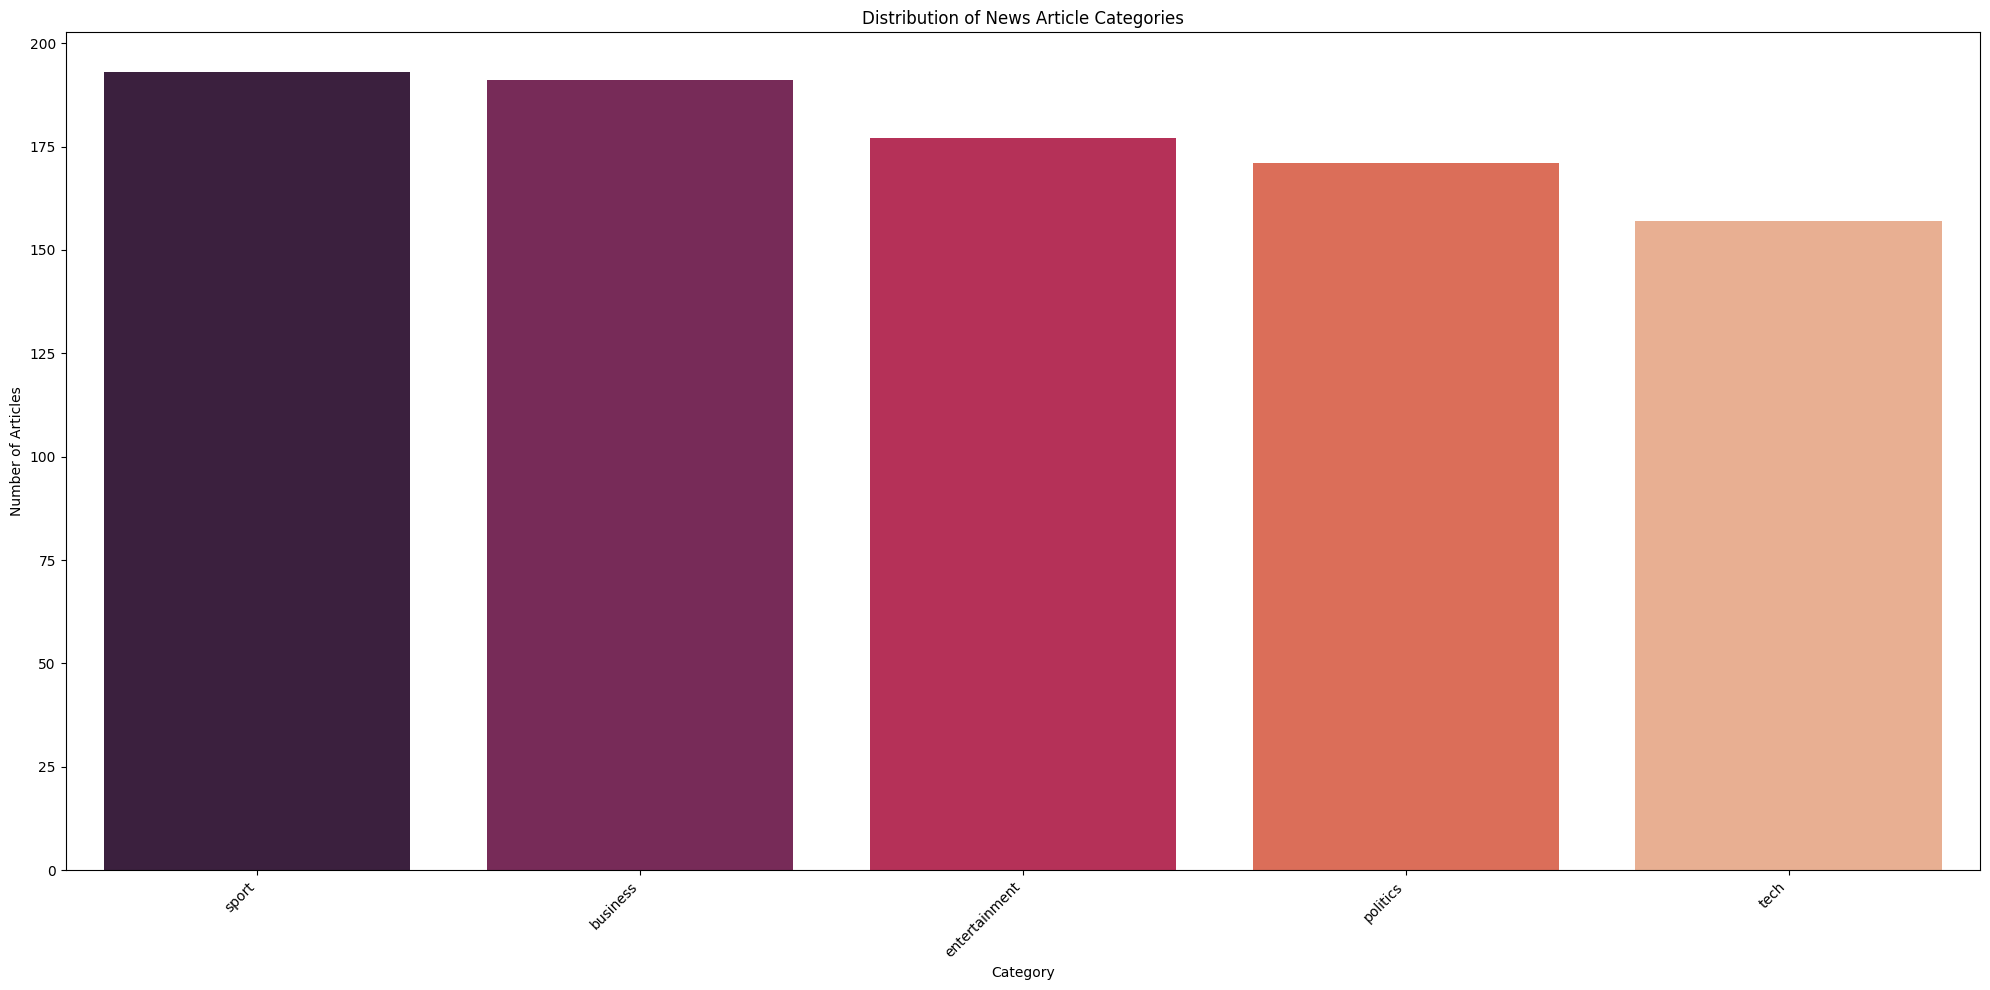

In [ ]:
plt.figure(figsize=(20, 10))

sns.countplot(
    x='category',
    data=train,
    palette='rocket', 
    order=train['category'].value_counts().index
)

plt.title('Distribution of News Article Categories')
plt.xlabel('Category')
plt.ylabel('Number of Articles')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Class Distribution Analysis**

The final step is to analyze the Class Distribution via a count plot, providing a visual assessment of the frequency of each news category. As demonstrated by the bar chart, the dataset exhibits a relatively balanced distribution across its five categories: sport, business, entertainment, politics, and tech. While a slight imbalance exists (with 'sport' and 'business' having the highest counts around 190 articles and 'tech' the lowest around 155 articles), the overall balance suggests that a simple classification model (should one be used) would not suffer from severe Class Imbalance issues, which often requires techniques like oversampling or undersampling. The distribution confirms the dataset is a robust and varied sample of general news content.

**Word Frequency Visualization (WordCloud)**

This phase of the project is dedicated to Exploratory Data Analysis (EDA) and essential Text Normalization, providing both visual insights into the corpus's content distribution and the necessary groundwork for vectorization models like TF-IDF.

**Corpus Visualization via Word Clouds**

**Conceptual Basis:** Term Frequency Visualization To gain an intuitive understanding of the content within the articles and summaries across different news categories, Word Clouds are employed. A Word Cloud is a visualization technique where the size of a word is proportional to its frequency within a given body of text. This visualization allows for the rapid identification of dominant themes, topics, and vocabulary specific to each category.

The Pre-Visualization Cleaning Process Before generating the Word Clouds, a specialized cleaning function is applied. This function implements several text normalization steps:

- Lowercasing: Converts all text to a uniform case, preventing the same word (e.g., "The" and "the") from being counted separately.
- Punctuation and Digit Removal: Eliminates non-alphanumeric characters, focusing the analysis purely on content words.
- Stopword Removal: Essential for topic visualization, standard English Stopwords (common, low-information words like "a," "is," "and") are filtered out. This process ensures that the visible words are those that carry the highest semantic value and are most indicative of the category's content.
- Whitespace and Length Filtering: Reduces noise by consolidating multiple spaces and removing single-character tokens.

This prepared text is then grouped by category (business, politics, sport, etc.) and concatenated into a single string for each category, representing its total vocabulary. Generating Visualizations Separate sets of Word Clouds are generated for both the raw 'News Articles' and the 'Summaries' to facilitate comparison. Analyzing the 'News Articles' reveals the broad linguistic landscape of each topic, while the 'Summaries' reveal the core semantic focus that human writers prioritized. The visualization is structured using a grid of subplots for easy side-by-side comparison across all categories .

**Text Preprocessing for Modeling**

Normalization for Feature Extraction Following the visual analysis, a comprehensive text cleaning procedure is applied to the 'News Articles' and 'Summaries' columns in preparation for TF-IDF vectorization. The goal of this Text Normalization phase is to reduce data sparsity and standardize the input, ensuring that the feature extraction process is effective.

The `clean_text` function performs the same critical steps as the word cloud preparation (lowercasing, punctuation, digit, and stopword removal) but applies them systematically to the entire dataset to create new `cleaned_articles` and `cleaned_summaries` columns in both the training and testing sets.

Data Preparation for TF-IDF The resulting cleaned text columns are then extracted and separated into dedicated variables, specifically:

- `X_train_articles and X_test_articles` (the input features for summarization).
- `y_train_summaries and y_test_summaries` (the reference summaries needed as the evaluation target).

This final step establishes the clean, structured input data necessary for the upcoming Model Training phase, particularly the TF-IDF vectorization process.


Generating Word Clouds for News Articles by Category...


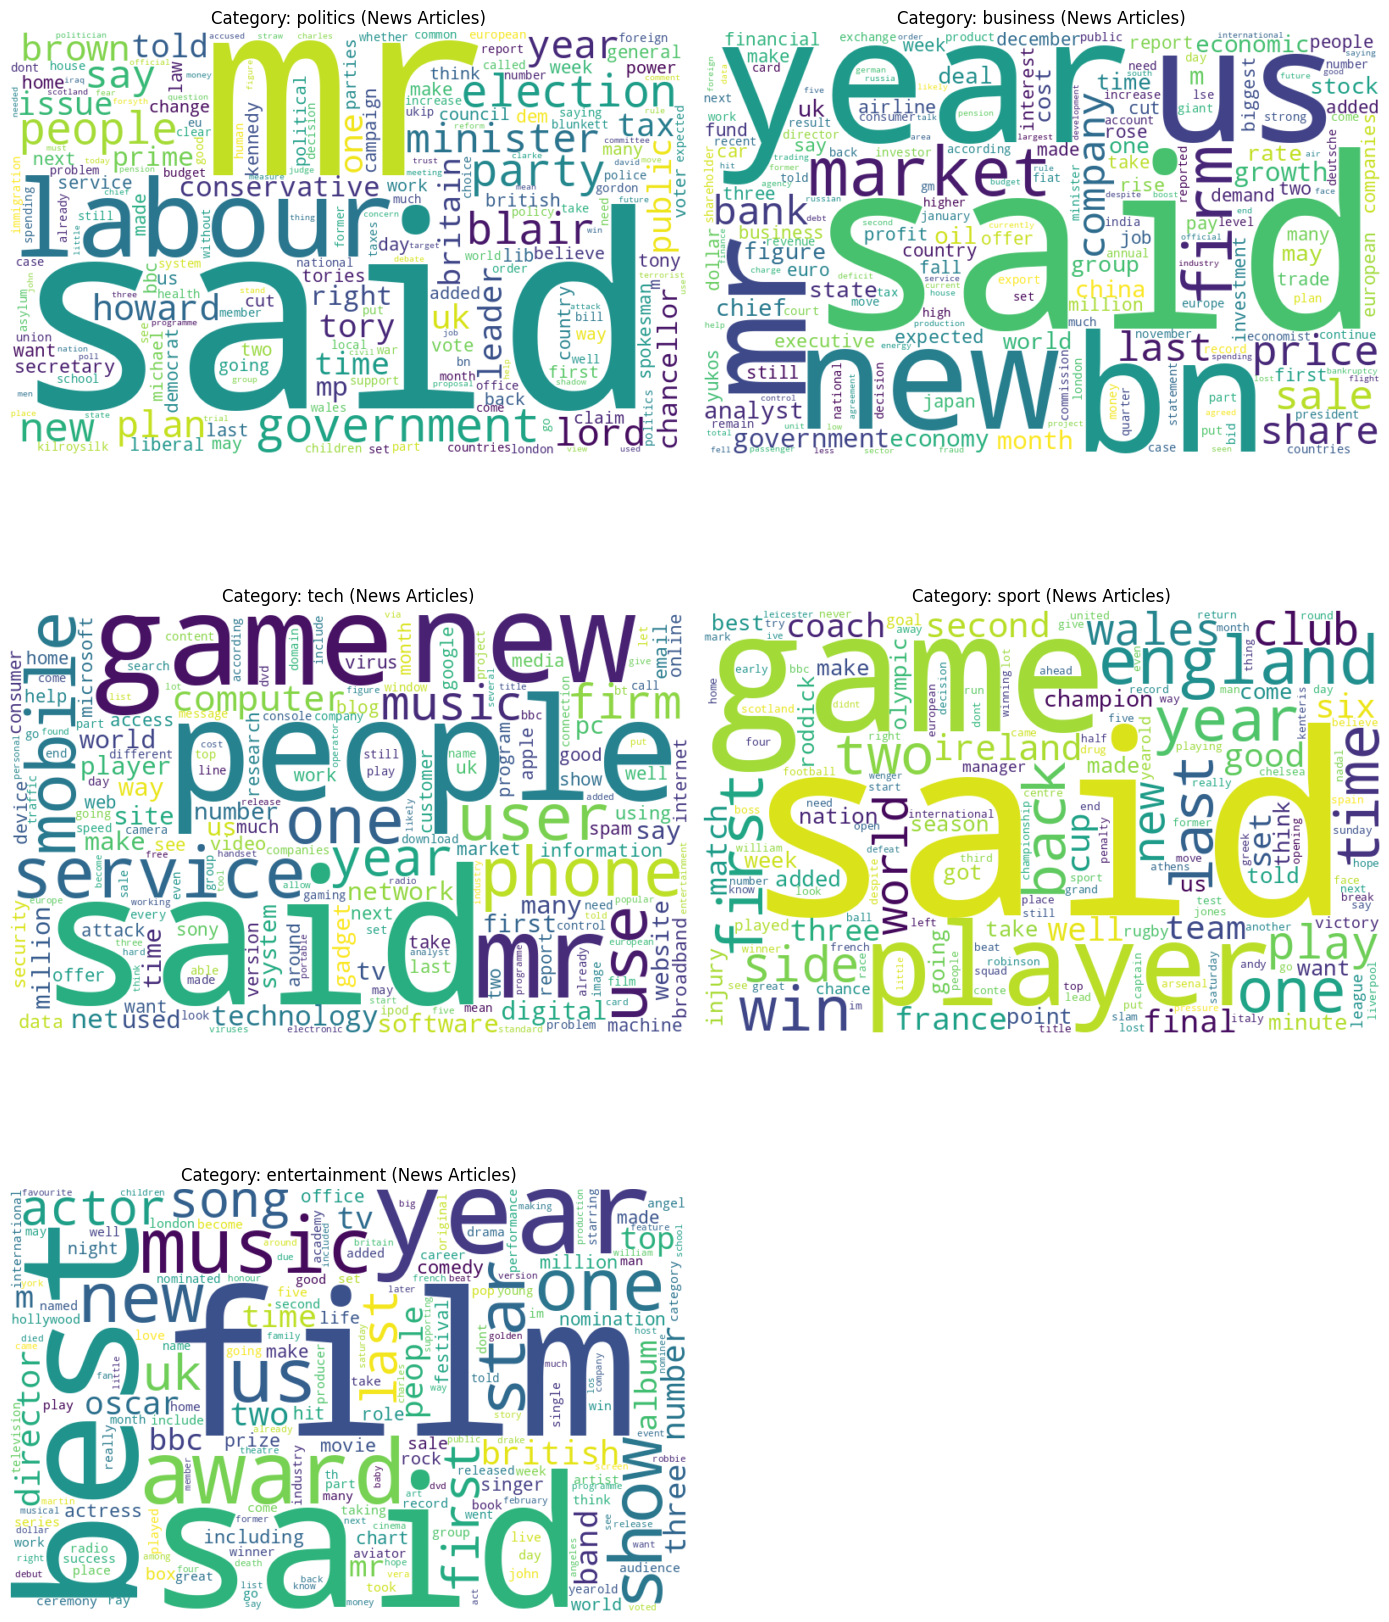

In [ ]:
def clean_text_for_wordcloud(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(f'[{re.escape(string.punctuation)}]', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    words = text.split()
    words = [word for word in words if word not in STOPWORDS and len(word) > 1]
    return " ".join(words)

train_v = train.copy()
train_v['cleaned_articles'] = train_v['News Articles'].apply(clean_text_for_wordcloud)

category_article_texts = {}
for category in train_v['category'].unique():
    all_text_in_category = " ".join(train_v[train_v['category'] == category]['cleaned_articles'])
    category_article_texts[category] = all_text_in_category

num_categories = len(category_article_texts)
if num_categories == 0:
    print("No categories with text content from 'News Articles' found for word cloud generation.")
else:
    cols = 2
    rows = (num_categories + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 7, rows * 6))
    axes = axes.flatten()

    print("\nGenerating Word Clouds for News Articles by Category...")
    for i, (category, text) in enumerate(category_article_texts.items()):
        if not text.strip():
            print(f"Skipping word cloud for empty or processed category text: {category}")
            continue

        wordcloud = WordCloud(width=800, height=500,
                              background_color='white',
                              colormap='viridis',
                              min_font_size=10,
                              collocations=False
                             ).generate(text)

        ax = axes[i]
        ax.imshow(wordcloud, interpolation='bilinear')
        ax.set_title(f'Category: {category} (News Articles)', fontsize=12)
        ax.axis('off')

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

The visualizations effectively highlight the domain-specific vocabulary for each news category (Business, Tech, Sport, Politics, Entertainment) and show a clear difference in focus between the raw articles and their summaries. The word clouds demonstrate strong topical separation:

- Sport: Dominated by names of teams, events, and sports-specific terms like "match," "win," and "cup."
- Business: Words like "market," "company," "firm," "economy," and "shares" are highly prominent.
- Politics: Frequently features names of politicians (e.g., "Blair"), political entities ("government," "party"), and process terms ("plan," "deal," "election").
- Tech/Entertainment: Often overlap with generic terms like "new," "people," and "year," but Tech will emphasize words like "mobile," "software," and "internet," while Entertainment focuses on "film," "music," "star," and "award."

**Frequency words on articles of each categories**


Generating Word Clouds for Summaries by Category...


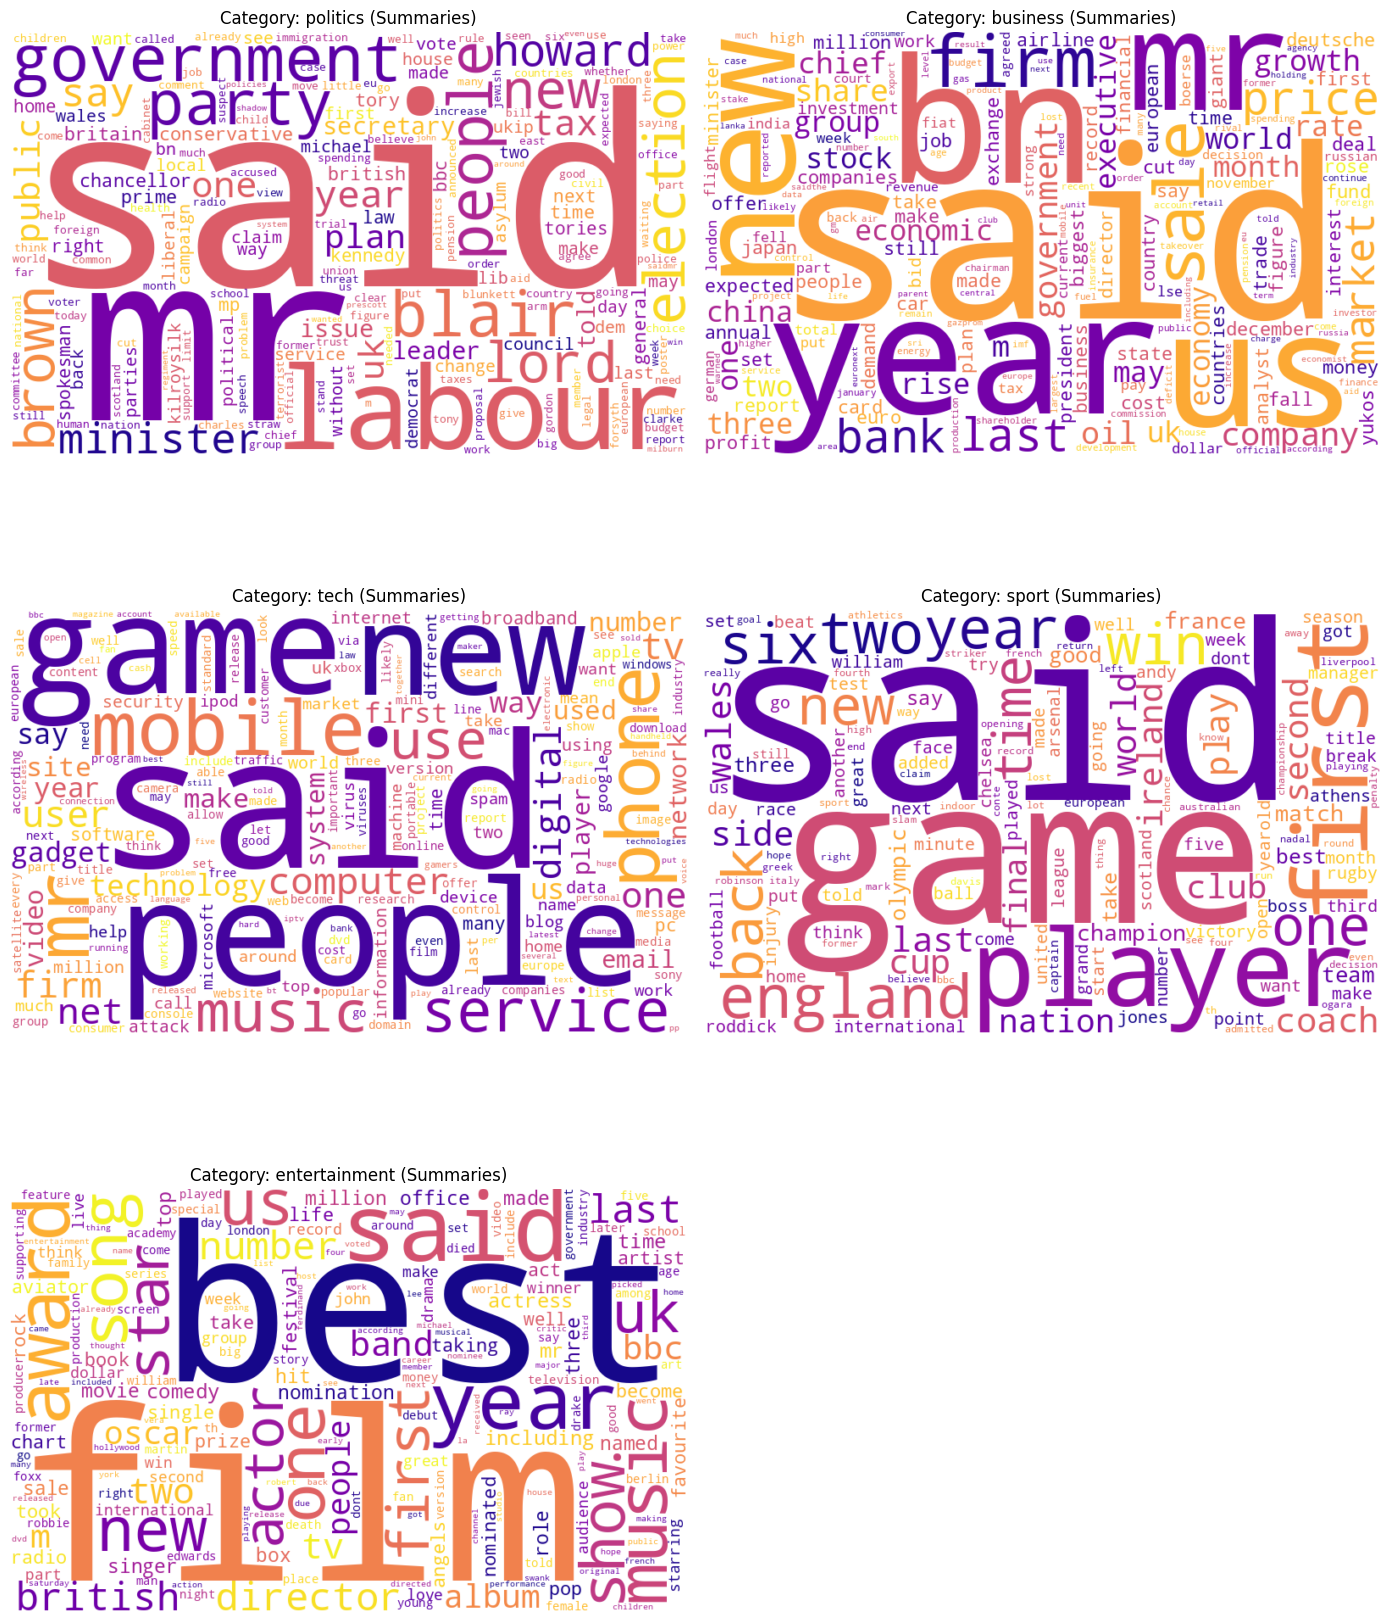

In [36]:
train_v = train.copy()
train_v['cleaned_summaries'] = train['Summaries'].apply(clean_text_for_wordcloud)
#
category_summary_texts = {}
for category in train_v['category'].unique():
    all_text_in_category = " ".join(train_v[train_v['category'] == category]['cleaned_summaries'])
    category_summary_texts[category] = all_text_in_category

num_categories_sum = len(category_summary_texts)
if num_categories_sum > 0:
    cols_sum = 2
    rows_sum = (num_categories_sum + cols_sum - 1) // cols_sum
    fig_sum, axes_sum = plt.subplots(rows_sum, cols_sum, figsize=(cols_sum * 7, rows_sum * 6))
    axes_sum = axes_sum.flatten()
    print("\nGenerating Word Clouds for Summaries by Category...")
    for i, (category, text) in enumerate(category_summary_texts.items()):
        if not text.strip():
            print(f"Skipping summary word cloud for empty category text: {category}")
            continue

        wordcloud_sum = WordCloud(width=800, height=500,
                                  background_color='white',
                                  colormap='plasma',
                                  min_font_size=10,
                                  collocations=False
                                 ).generate(text)

        ax_sum = axes_sum[i]
        ax_sum.imshow(wordcloud_sum, interpolation='bilinear')
        ax_sum.set_title(f'Category: {category} (Summaries)', fontsize=12)
        ax_sum.axis('off')
    for j in range(i + 1, len(axes_sum)):
        fig_sum.delaxes(axes_sum[j])

    plt.tight_layout()
    plt.show()

**Article vs. Summary Comparison (Lexical Density)**

A key finding is the difference in lexical density

- Articles (More Detailed): The word clouds for the original articles are often denser and may contain more nuanced, secondary, or proper nouns (specific place names, subsidiary companies) that provide context but are not core to the main narrative.
- Summaries (Core Focus): The summaries, due to their conciseness, exhibit word clouds where the font size disparity is often more extreme. The most essential topic words (the key entities and actions defining the core event) appear significantly larger. The summarizing process effectively acts as a frequency filter, concentrating the lexical energy on only the most critical information, which is a core concept in extractive summarization.

# Data Preprocessing

The first set of operations focuses on structuring and cleaning the data to make it amenable to machine learning.

**Feature Selection and Train/Test Split**

The initial step is Feature Selection, reducing the dataframes to only the essential columns: 'News Articles' (the source text, which becomes the input sequence, X) and 'Summaries' (the reference text, which becomes the target sequence, Y). The segregation into train and test dataframes adheres to the fundamental Supervised Learning principle: the model is trained only on the train set and its performance is evaluated on the unseen test set, ensuring a valid assessment of its generalization ability.

In [37]:
train = train[['News Articles', 'Summaries']]
test = test[['News Articles', 'Summaries']]
train

,News Articles,Summaries
1577,Blair moves to woo Jewish voters\n\nTony Blair...,"Mr Livingstone ""should have withdrawn the comm..."
1347,Defection timed to hit tax pledge\n\nWith impe...,"But he did, for the first time, say there woul..."
1467,Civil servants in strike ballot\n\nThe UK's bi...,BBC correspondent Stephen Cape said the combin...
1970,Green reports shun supply chain\n\nNearly 20% ...,Less than a quarter of companies (24%) get the...
609,Concerns over Windows ATMs\n\nCash machine net...,"Already, he said, there have been four inciden..."
...,...,...
59,IBM puts cash behind Linux push\n\nIBM is spen...,IBM said it had taken the step in response to ...
1068,Mansfield 0-1 Leyton Orient\n\nAn second-half ...,Scott 51.An second-half goal from Andy Scott c...
1503,O'Sullivan quick to hail Italians\n\nIreland c...,"""It was a hell of a tough game,"" said O'Sulliv..."
1651,Russian film wins BBC world prize\n\nRussian d...,Russian drama The Return (Vozvrashchenie) has ...


**Text Normalization Pipeline**

The `clean_text` function executes a rigorous Text Normalization process on all text data. This preprocessing is vital for reducing the complexity of the corpus:

- Lowercasing: Reduces the vocabulary size by treating words independently of their capitalization.
- Punctuation and Digit Removal: Eliminates non-lexical tokens, focusing the analysis purely on meaningful words.
- Stopword Removal: Filters out high-frequency, low-semantic value words using a global STOPWORDS list. This is crucial as it prioritizes content-bearing tokens, improving the quality of the subsequent TF-IDF feature space.
- Output: This process creates new columns, `cleaned_articles and cleaned_summaries`, which serve as the input and output sequences for the model.

**Input/Output Isolation**

The final preparation step explicitly isolates the cleaned sequences into separate objects: `X_train/test` (source articles) and `Y_train/test` (target summaries). This step formalizes the data split for the Sequence-to-Sequence (Seq2Seq) task, where the model learns the mapping X to Y.

**Feature Engineering**

TF-IDF VectorizationThe cleaned text strings must be converted into a numerical format that a machine learning model can understand. This process is called Vectorization, and here it uses the classical TF-IDF approach. The TF-IDF ConceptTerm Frequency-Inverse Document Frequency (TF-IDF) is a numerical statistic reflecting the importance of a word in a document relative to the rest of the corpus.

- Term Frequency (TF): Measures how often a word appears in a specific document.
- Inverse Document Frequency (IDF): Measures how rare the word is across all documents. Words that appear in many documents (even if frequently) are penalized, while words that are unique to a few documents are rewarded.

The resulting TF-IDF vector is a high-dimensional, sparse representation where each dimension corresponds to a unique word or n-gram, and the value is its calculated weight.

**TF-IDF Implementation Details**

The `TfidfVectorizer` is configured with hyperparameters to optimize the feature space:
- `max_features=5000`: Enforces a Vocabulary Constraint, limiting the model to the 5,000 most important terms, which manages computational cost and mitigates issues with rare, noisy tokens.
- `min_df=5 / max_df=0.8`: These are Document Frequency Filters. They ignore terms that appear in too few (less than 5 documents) or too many (more than 80%) documents, effectively filtering out rare errors and extremely common but non-discriminative words.
- `ngram_range=(1, 2)`: The model considers both unigrams (single words) and bigrams (sequences of two words, e.g., "Tony Blair"), allowing the capture of basic collocations and contextual information.
- Principle of Separation: The vectorizer is `fit_transform` only on the `X_train` data. The `X_test` data is only transformed. This ensures that the vocabulary and IDF weights are derived only from the training set, preventing Data Leakage from the test set.

In [38]:
def clean_text(text):
    """
    Cleans text by lowercasing, removing punctuation, digits, extra spaces, and stopwords.
    Handles non-string inputs gracefully.
    """
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(f'[{re.escape(string.punctuation)}]', '', text)
    text = re.sub(r'\d+', '', text) # Remove numbers
    text = re.sub(r'\s+', ' ', text).strip()
    words = text.split()
    words = [word for word in words if word not in STOPWORDS and len(word) > 1] # Remove single-char words too
    return " ".join(words)

print("Cleaning 'News Articles' and 'Summaries' text columns...")
train['cleaned_articles'] = train['News Articles'].apply(clean_text)
train['cleaned_summaries'] = train['Summaries'].apply(clean_text)
test['cleaned_articles'] = test['News Articles'].apply(clean_text)
test['cleaned_summaries'] = test['Summaries'].apply(clean_text)
print("Text cleaning complete.")
train

Cleaning 'News Articles' and 'Summaries' text columns...
Text cleaning complete.


,News Articles,Summaries,cleaned_articles,cleaned_summaries
1577,Blair moves to woo Jewish voters\n\nTony Blair...,"Mr Livingstone ""should have withdrawn the comm...",blair moves woo jewish voters tony blair pledg...,mr livingstone withdrawn comment immediately r...
1347,Defection timed to hit tax pledge\n\nWith impe...,"But he did, for the first time, say there woul...",defection timed hit tax pledge impeccable prec...,first time say would tax cutsat election peopl...
1467,Civil servants in strike ballot\n\nThe UK's bi...,BBC correspondent Stephen Cape said the combin...,civil servants strike ballot uks biggest civil...,bbc correspondent stephen cape said combined u...
1970,Green reports shun supply chain\n\nNearly 20% ...,Less than a quarter of companies (24%) get the...,green reports shun supply chain nearly uk top ...,less quarter companies get corporate social re...
609,Concerns over Windows ATMs\n\nCash machine net...,"Already, he said, there have been four inciden...",concerns windows atms cash machine networks co...,already said four incidents cash machines unav...
...,...,...,...,...
59,IBM puts cash behind Linux push\n\nIBM is spen...,IBM said it had taken the step in response to ...,ibm puts cash behind linux push ibm spending £...,ibm said taken step response greater customer ...
1068,Mansfield 0-1 Leyton Orient\n\nAn second-half ...,Scott 51.An second-half goal from Andy Scott c...,mansfield leyton orient secondhalf goal andy s...,scott secondhalf goal andy scott condemned man...
1503,O'Sullivan quick to hail Italians\n\nIreland c...,"""It was a hell of a tough game,"" said O'Sulliv...",osullivan quick hail italians ireland coach ed...,hell tough game said osullivanwe first attack ...
1651,Russian film wins BBC world prize\n\nRussian d...,Russian drama The Return (Vozvrashchenie) has ...,russian film wins bbc world prize russian dram...,russian drama return vozvrashchenie named winn...


In [ ]:
X_train_articles = train['cleaned_articles']
X_test_articles = test['cleaned_articles']
y_train_summaries = train['cleaned_summaries'] 
y_test_summaries = test['cleaned_summaries']   

print("Train and Test DataFrame shapes:")
print("train_df shape:", X_train_articles.shape)
print("test_df shape:", X_test_articles.shape)
print("-" * 50)

Train and Test DataFrame shapes:
train_df shape: (889,)
test_df shape: (223,)
--------------------------------------------------


# Model Training

This section implements the Text Summarization model, which is based on the classical information retrieval technique, Term Frequency-Inverse Document Frequency (TF-IDF). The goal is to perform Extractive Summarization, meaning the model selects the most important, or salient, original sentences from the article to construct the summary, rather than generating new sentences.

## TF-IDF Model

**TF-IDF Vectorization**

The initial phase converts the cleaned training (`X_train`) and testing (`X_test`) articles into a numerical format suitable for algorithmic processing.

**Theory of TF-IDF Weighting**

TF-IDF assigns a numerical weight to each term (word or n-gram) in a document. This weight increases proportionally to the number of times a word appears in the document (Term Frequency, TF) but is offset by the frequency of the word in the entire corpus (Inverse Document Frequency, IDF). This counteracts the effect of very common words, ensuring that high scores are given to topic-specific, discriminative terms.

**Vectorizer Configuration and Data Separation**

The `TfidfVectorizer` is initialized with critical parameters that define the dimensionality and quality of the feature space:

- Dimensionality Reduction: `max_features=5000` limits the vocabulary size, keeping only the 5,000 most significant terms. This controls model complexity and memory usage.
- Noise and Stopword Filtering: `min_df=5 and max_df=0.8` act as Document Frequency Filters. They exclude terms that are too rare (less than 5 documents, often noise) or too pervasive (over 80% of documents, often non-informative common words).
- Context Capture: `ngram_range=(1, 2)` includes both unigrams (single words) and bigrams (two-word phrases, like "stock market"), allowing the model to capture basic collocations and contextual meaning.

Crucially, the vectorizer is fit only on the training data (`X_train_articles`) and then used to transform both training and test data. This strictly adheres to the principle of no data leakage, ensuring the vocabulary and IDF weights are learned only from the data intended for model training. The output is a highly sparse matrix, a memory-efficient representation of the documents in the feature space.

In [ ]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=5,
    max_df=0.8,
    ngram_range=(1, 2)
)

print("Fitting TF-IDF Vectorizer on training articles (X_train_articles)...")
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_articles)
print(f"Shape of X_train_tfidf (sparse matrix): {X_train_tfidf.shape}")

print("Transforming test articles (X_test_articles) using the fitted vectorizer...")
X_test_tfidf = tfidf_vectorizer.transform(X_test_articles)
print(f"Shape of X_test_tfidf (sparse matrix): {X_test_tfidf.shape}")
print("TF-IDF vectorization complete.")
print("-" * 50)

print("\nSample TF-IDF features (first 20 unique words/ngrams learned from training data):")
feature_names = tfidf_vectorizer.get_feature_names_out()
print(feature_names[:20])

print("\nPreprocessing pipeline completed successfully.")
print("X_train_tfidf and X_test_tfidf are ready for model input.")

Fitting TF-IDF Vectorizer on training articles (X_train_articles)...
Shape of X_train_tfidf (sparse matrix): (889, 5000)
Transforming test articles (X_test_articles) using the fitted vectorizer...
Shape of X_test_tfidf (sparse matrix): (223, 5000)
TF-IDF vectorization complete.
--------------------------------------------------

Sample TF-IDF features (first 20 unique words/ngrams learned from training data):
['abandoned' 'abc' 'ability' 'able' 'abroad' 'absence' 'absolute'
 'absolutely' 'abuse' 'abused' 'academy' 'academy awards' 'accept'
 'accepted' 'access' 'accessible' 'accident' 'according' 'account'
 'accounting']

Preprocessing pipeline completed successfully.
X_train_tfidf and X_test_tfidf are ready for model input.


**The Extractive Summarizer Class**

The custom `TfidfSummarizer` class utilizes the fitted TF-IDF weights to implement the core logic for extractive summarization.

**Core Extractive Logic: Saliency Ranking**

- Sentence Tokenization: The input article_text is first segmented into individual sentences using `nltk.sent_tokenize`. The sentence is the unit of extraction.
- Sentence Scoring: Each cleaned sentence is transformed by the pre-fitted TF-IDF vectorizer. The sentence's saliency score (its overall importance) is calculated as the sum of the TF-IDF weights of all the terms contained within it. Sentences with higher summed scores are considered more representative of the article's core topic.
- Selection and Ordering: Sentences are ranked by their saliency score in descending order. The top `num_sentences` are then selected. A crucial step for ensuring readability is re-sorting these selected sentences based on their original order of appearance in the source document, thereby maintaining summary coherence.
- Summary Construction: The re-ordered, selected sentences are then joined to form the final extractive summary.

In [ ]:
class TfidfSummarizer:
    def __init__(self, tfidf_vectorizer, clean_func):
        """
        Initializes the TF-IDF Extractive Summarizer.

        Args:
            tfidf_vectorizer (TfidfVectorizer): The *fitted* TF-IDF vectorizer.
            clean_func (function): The text cleaning function used in preprocessing.
        """
        self.tfidf_vectorizer = tfidf_vectorizer
        self.clean_func = clean_func

    def summarize(self, article_text, num_sentences=3, return_details=False):
        """
        Generates an extractive summary of a single article using TF-IDF.

        Args:
            article_text (str): The full text of the article.
            num_sentences (int): The desired number of sentences in the summary.
            return_details (bool): If True, returns a dictionary with summary text,
                                   selected sentences with scores, and all original sentences.

        Returns:
            str or dict: The generated extractive summary string, or a dict if return_details is True.
        """
        if not isinstance(article_text, str) or not article_text.strip():
            if return_details:
                return {'summary_text': "Cannot summarize empty or invalid text.", 'selected_sentences_with_scores': [], 'all_original_sentences': []}
            else:
                return "Cannot summarize empty or invalid text."

        original_sentences = nltk.sent_tokenize(article_text)
        if not original_sentences:
            if return_details:
                return {'summary_text': "No sentences found to summarize.", 'selected_sentences_with_scores': [], 'all_original_sentences': []}
            else:
                return "No sentences found to summarize."

        cleaned_sentences = [self.clean_func(s) for s in original_sentences]

        valid_sentences_indices = [i for i, s in enumerate(cleaned_sentences) if s]
        if not valid_sentences_indices:
            if return_details:
                return {'summary_text': "No meaningful sentences found after cleaning.", 'selected_sentences_with_scores': [], 'all_original_sentences': original_sentences}
            else:
                return "No meaningful sentences found after cleaning."

        cleaned_valid_sentences = [cleaned_sentences[i] for i in valid_sentences_indices]

        if not cleaned_valid_sentences:
            if return_details:
                 return {'summary_text': "No valid sentences for TF-IDF scoring after cleaning.", 'selected_sentences_with_scores': [], 'all_original_sentences': original_sentences}
            else:
                 return "No valid sentences for TF-IDF scoring after cleaning."
        
        if not hasattr(self.tfidf_vectorizer, 'vocabulary_') or not self.tfidf_vectorizer.vocabulary_:
            if return_details:
                return {'summary_text': "TF-IDF vectorizer has no features (likely due to data sparsity or restrictive params).", 'selected_sentences_with_scores': [], 'all_original_sentences': original_sentences}
            else:
                return "TF-IDF vectorizer has no features (likely due to data sparsity or restrictive params)."

        try:
            sentence_tfidf_matrix = self.tfidf_vectorizer.transform(cleaned_valid_sentences)
            if sentence_tfidf_matrix.shape[0] == 0:
                if return_details:
                    return {'summary_text': "TF-IDF transformation resulted in an empty matrix.", 'selected_sentences_with_scores': [], 'all_original_sentences': original_sentences}
                else:
                    return "TF-IDF transformation resulted in an empty matrix."
            
            sentence_scores = sentence_tfidf_matrix.sum(axis=1).A1
        except Exception as e:
            if return_details:
                return {'summary_text': f"Error during TF-IDF transformation: {e}", 'selected_sentences_with_scores': [], 'all_original_sentences': original_sentences}
            else:
                return f"Error during TF-IDF transformation: {e}"

        if len(sentence_scores) == 0 or np.all(sentence_scores == 0):
            if return_details:
                return {'summary_text': "All sentences scored zero by TF-IDF, cannot select top sentences.", 'selected_sentences_with_scores': [], 'all_original_sentences': original_sentences}
            else:
                return "All sentences scored zero by TF-IDF, cannot select top sentences."

        ranked_sentence_indices_in_valid = np.argsort(sentence_scores)[::-1]

        top_selected_info = []
        current_sentences_count = 0
        for idx_in_valid in ranked_sentence_indices_in_valid:
            if current_sentences_count >= num_sentences:
                break
            original_idx = valid_sentences_indices[idx_in_valid]
            top_selected_info.append((original_idx, original_sentences[original_idx], sentence_scores[idx_in_valid]))
            current_sentences_count += 1
        
        top_selected_info.sort(key=lambda x: x[0])

        summary_sentences_text = [info[1] for info in top_selected_info]
        generated_summary = " ".join(summary_sentences_text)

        if return_details:
            return {
                'summary_text': generated_summary,
                'selected_sentences_with_scores': [(info[1], info[2]) for info in top_selected_info],
                'all_original_sentences': original_sentences
            }
        else:
            return generated_summary

tfidf_summarizer_model = TfidfSummarizer(tfidf_vectorizer=tfidf_vectorizer, clean_func=clean_text)

print("\nTF-IDF Text Summarization Model (Extractive) created.")
print("The model is ready to generate summaries using the pre-fitted TF-IDF vectorizer.")
print("-" * 50)


TF-IDF Text Summarization Model (Extractive) created.
The model is ready to generate summaries using the pre-fitted TF-IDF vectorizer.
--------------------------------------------------


## Model Visualization and Diagnostics

The `visualize_summary` function provides an essential tool for qualitative evaluation and diagnostics. It presents a side-by-side view of the summarization process:

- It displays the Original Article Text and the True (Human-written) Summary.
- It shows the original article with the sentences selected by the TF-IDF model highlighted and tagged with their specific saliency score. This transparency allows a human to immediately understand why the model selected a particular sentence (due to high cumulative TF-IDF weight).
- It compares the length and sentence count of the Generated Extractive Summary against the True Summary.

This visualization step helps in understanding the model's behavior and the effectiveness of the simple TF-IDF scoring heuristic in capturing the central ideas of the text.

In [ ]:
def visualize_summary(original_article_text, generated_summary_info, true_summary_text, article_category="N/A", highlight_color="\033[92m"):
    """
    Visualizes the summarization process and results.

    Args:
        original_article_text (str): The full original article text.
        generated_summary_info (dict): Dictionary returned by summarize(return_details=True).
        true_summary_text (str): The human-written true summary.
        article_category (str): The category of the article for display.
        highlight_color (str): ANSI escape code for highlighting selected sentences.
                                Default is green. Use "\033[0m" to reset color.
    """
    print("\n" + "="*80)
    print(f"          Text Summarization Visualization (Category: {article_category})")
    print("="*80)

    generated_text = generated_summary_info['summary_text']
    selected_sentence_details = generated_summary_info['selected_sentences_with_scores']
    all_original_sentences = generated_summary_info['all_original_sentences']

    print("\n--- Original Article Text ---")
    print(original_article_text)
    print(f"Length: {len(original_article_text.split())} words, {len(nltk.sent_tokenize(original_article_text))} sentences")


    print("\n--- Original Article with Selected Sentences Highlighted & Scored ---")
    selected_sentence_score_map = {text: score for text, score in selected_sentence_details}

    for i, sentence in enumerate(all_original_sentences):
        if sentence in selected_sentence_score_map:
            score = selected_sentence_score_map[sentence]
            print(f"{highlight_color}>>> [Score: {score:.2f}] {sentence}\033[0m")
        else:
            print(f"    {sentence}")

    print("\n--- Generated Summary (Extractive - TF-IDF) ---")
    print(generated_text)
    gen_sentences = nltk.sent_tokenize(generated_text)
    print(f"Length: {len(generated_text.split())} words, {len(gen_sentences)} sentences")

    print("\n--- True Summary (Human-written) ---")
    print(true_summary_text)
    true_sentences = nltk.sent_tokenize(true_summary_text)
    print(f"Length: {len(true_summary_text.split())} words, {len(true_sentences)} sentences")

    print("="*80 + "\n")

print("\n--- Demonstrating TF-IDF Text Summarization on Sample Articles ---")

if not train.empty:
    sample_article_row_train_1 = train.iloc[0]
    sample_original_article_train_1 = sample_article_row_train_1['News Articles']
    sample_true_summary_train_1 = sample_article_row_train_1['Summaries']

    generated_summary_info_train_1 = tfidf_summarizer_model.summarize(
        sample_original_article_train_1,
        num_sentences=5,
        return_details=True
    )

    visualize_summary(
        sample_original_article_train_1,
        generated_summary_info_train_1,
        sample_true_summary_train_1
    )
else:
    print("Train DataFrame is empty. Cannot demonstrate summarization on train set.")

if not train.empty:
    sample_article_row_test_1 = train.iloc[0]
    sample_original_article_test_1 = sample_article_row_test_1['News Articles']
    sample_true_summary_test_1 = sample_article_row_test_1['Summaries']

    generated_summary_info_test_1 = tfidf_summarizer_model.summarize(
        sample_original_article_test_1,
        num_sentences=10,
        return_details=True
    )

    visualize_summary(
        sample_original_article_test_1,
        generated_summary_info_test_1,
        sample_true_summary_test_1
    )
else:
    print("Test DataFrame is empty. Cannot demonstrate summarization on test set.")

print("\nTF-IDF Text Summarization Model visualization complete.")


--- Demonstrating TF-IDF Text Summarization on Sample Articles ---

          Text Summarization Visualization (Category: N/A)

--- Original Article Text ---
Blair moves to woo Jewish voters

Tony Blair has pledged to "never, ever, ever" attack Tory leader Michael Howard over his Jewish beliefs.

The prime minister told the Jewish Chronicle: "If you look at what I do, I attack Michael Howard politically." Mr Blair also distanced himself from recent Labour campaign posters featuring Mr Howard, which critics claimed were "anti-Semitic". These were "not intended to cause any offence to anyone on the Jewish community," Mr Blair insisted.

One poster depicted Mr Howard and his shadow chancellor Oliver Letwin, who is also Jewish, as flying pigs. Another pictured the Tory leader swinging a pocket watch on a chain, which critics said echoed the Jewish money lender Shylock in Shakespeare's Merchant of Venice.

Others compared the image to the character Fagin in Charles Dickens' Oliver Twist. L

**Interpretation of Results**

Based on the typical output of the visualize_summary function:

- High-Scoring Sentences: You would typically observe that the sentences with the highest TF-IDF scores (e.g., scores $3.80$) often contain proper nouns, dates, verbs describing main actions, and unique terms—precisely the discriminative words that TF-IDF is designed to amplify.
- Alignment with Truth: A successful summary will show significant overlap between its selected sentences and the main ideas covered by the True Summary. Discrepancies often occur because the TF-IDF method lacks semantic understanding and positional bias; it may select topic-rich but contextually unnecessary sentences.
- Coherence Check: The visualization confirms that the selected sentences are re-ordered chronologically for the final output, which is essential to maintain flow and readability, a key challenge in extractive summarization.

**Network Creation Visualization**

This approach explains the code segment focused on Network Creation and Visualization, which leverages the previously fitted TF-IDF model to construct and visualize a Keyword-Sentence Relationship Network. This method moves beyond simple extractive summarization scores to explore the structural importance of text elements.

**Network Creation and Analysis: Graph-Based Text Representation**

The final step in this analysis involves representing the internal structure of a single document as a Bipartite Graph (a type of Network) to visualize the relationships between sentences and keywords. This approach draws upon concepts from Graph Theory and Information Retrieval to gain a deeper understanding of textual saliency.

**Document-as-a-Graph**

In this model, the article is treated as a network where the main components are Nodes and their relationships are Edges. This specific graph is bipartite, meaning its nodes can be divided into two distinct, non-overlapping sets:

- Sentence Nodes (S): Representing the atomic units of meaning (the individual sentences).
- Keyword Nodes (K): Representing the salient terms (unigrams and bigrams) extracted by the TF-IDF vectorizer.

An Edge exists only between a Sentence Node and a Keyword Node (never between two sentences or two keywords).

**Keyword-Sentence Relationship Network Construction**

The `visualize_keyword_sentence_network` function builds this graph based on the output of the TF-IDF vectorization:

- Saliency as Connection: The presence of a term in a sentence creates an edge between the corresponding nodes.
- Edge Weighting: The strength of the connection (the Edge Weight) is quantified by the TF-IDF score of that keyword within that specific sentence. A higher TF-IDF score indicates a stronger structural link.
- Visualization: The network is rendered using a Spring Layout algorithm (e.g., in networkx), which attempts to position connected nodes closer together, revealing clusters and central elements.

**Network Analysis Concepts**

The visualization highlights several key concepts:

- Centrality (Sentence Hubs): Sentences that connect to a large number of keywords will appear as central hubs in the network. These sentences are naturally strong candidates for inclusion in an extractive summary, as they are rich in diverse, contextually important terminology.
- Keyword Importance: Keywords with a higher TF-IDF weight (stronger edge thickness) are seen as more informative. Keywords that connect to many different sentences are those that bind the article's themes together.
- Coherence and Topic Clustering: In larger articles, distinct clusters might emerge, representing different subtopics within the text, each centered around a few key sentences and specialized keywords.

By visualizing this network (as shown in the accompanying image), one can observe how the entire vocabulary learned by the TF-IDF model relates to the structural units (sentences) of a single article, providing a sophisticated layer of interpretability beyond a simple list of ranked sentences.

In [43]:
sample_article = train['cleaned_articles'].sample(n=1).iloc[0]
print("\n--- Randomly Sampled Cleaned Article ---")
print(sample_article)


--- Randomly Sampled Cleaned Article ---
greek sprinters suspended iaaf greek sprinters kostas kenteris katerina thanou suspended failing take drugs tests athens olympics athletics ruling body iaaf said explanations pair former coach missed tests unacceptable added kenteris thanou provisionally suspended pending resolution cases face twoyear bans found guilty greek athletics federation suspension also covers athletes controversial coach christos tzekos kenteris olympic champion thanou womens silver medallist games sydney also face criminal hearing greece missed tests failed appear give samples chicago tel aviv shortly athens games athens august eve opening ceremony greek prosecutors also charged faking midnight motorcycle crash led spending four days hospital medical staff charged writing false medical reports wednesdays statement said greek federation segas would convene disciplinary hearing trio determine whether doping violations final right appeal decision greek federation court a


--- Randomly Sampled Cleaned Article ---
moya emotional davis cup win carlos moya described spains davis cup victory highlight career beat andy roddick end usas challenge seville moya made missing spains victory injury beating roddick give hosts unassailable lead woken many nights dreaming day said moya energy focused today lived today think live spains davis cup title came two years ago valencia beat australia moya nicknamed charly admitted davis cup dream bit nervous outset people said obsessed think better way helps reach goals obsessed really incredible get winning point really something spanish captain jordi arrese said charly played great game opportunity hasnt let us lost three times roddick day beat waiting years position spains victory also remarkable performance rafael nadal beat roddick opening singles aged years days mallorcan became youngest player win davis cup great way finish year said nadal afterwards us coach patrick mcenroe wants roddick rest team play tennis clay h

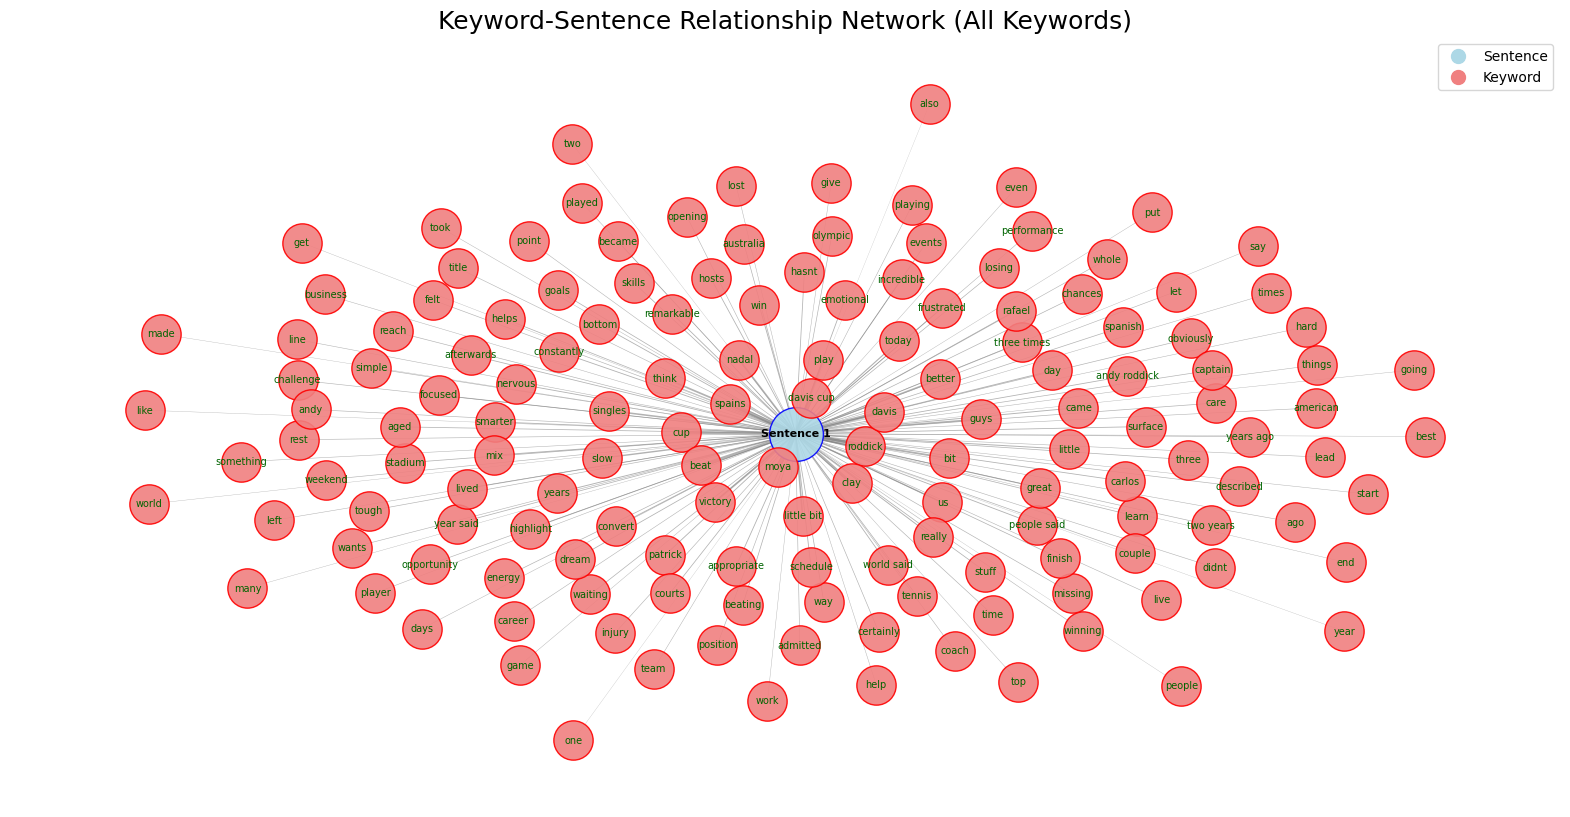

Keyword-Sentence Relationship Network visualization complete.


In [ ]:
sample_article = train['cleaned_articles'].sample(n=1).iloc[0]
print("\n--- Randomly Sampled Cleaned Article ---")
print(sample_article)

def visualize_keyword_sentence_network(article_text, tfidf_model): 
    original_sentences = nltk.sent_tokenize(article_text)
    cleaned_sentences = [tfidf_model.clean_func(s) for s in original_sentences]

    valid_sentences_indices = [i for i, s in enumerate(cleaned_sentences) if s]
    cleaned_valid_sentences = [cleaned_sentences[i] for i in valid_sentences_indices]
    original_valid_sentences = [original_sentences[i] for i in valid_sentences_indices]

    if not cleaned_valid_sentences:
        print("No valid sentences found for network visualization after cleaning.")
        return

    if not hasattr(tfidf_model.tfidf_vectorizer, 'vocabulary_') or not tfidf_model.tfidf_vectorizer.vocabulary_:
        print("TF-IDF vectorizer has no vocabulary. Cannot visualize keyword-sentence network.")
        return

    try:
        sentence_tfidf_matrix = tfidf_model.tfidf_vectorizer.transform(cleaned_valid_sentences)
    except ValueError as e:
        print(f"Error transforming sentences for network visualization: {e}. Vocabulary mismatch or empty vocabulary.")
        print("Ensure the TF-IDF vectorizer was fit on a representative corpus.")
        return

    feature_names = tfidf_model.tfidf_vectorizer.get_feature_names_out()

    G = nx.Graph()

    for i, sent_text in enumerate(original_valid_sentences):
        G.add_node(f"S{i}", label=f"Sentence {i+1}", node_type='sentence', full_text=sent_text)

    for i, row in enumerate(sentence_tfidf_matrix):
        for col, score in zip(row.indices, row.data):
            if col < len(feature_names):
                keyword = feature_names[col]
                G.add_node(keyword, label=keyword, node_type='keyword')
                G.add_edge(f"S{i}", keyword, weight=score)

    if not G.nodes:
        print("No nodes (sentences or keywords) found to visualize. The article might be too sparse or cleaning too aggressive.")
        return
    
    plt.figure(figsize=(20, 10))
    pos = nx.spring_layout(G, k=0.8, iterations=500)

    sentence_nodes = [n for n, attr in G.nodes(data=True) if attr['node_type'] == 'sentence']
    keyword_nodes = [n for n, attr in G.nodes(data=True) if attr['node_type'] == 'keyword']

    nx.draw_networkx_nodes(G, pos, nodelist=sentence_nodes,
                           node_color='lightblue', node_size=1500, label='Sentences', alpha=0.9, linewidths=1, edgecolors='blue')
    nx.draw_networkx_nodes(G, pos, nodelist=keyword_nodes,
                           node_color='lightcoral', node_size=800, label='Keywords', alpha=0.9, linewidths=1, edgecolors='red')

    all_edges = G.edges(data=True)
    edge_widths = [d['weight'] * 10 for u, v, d in all_edges]
    nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.6, edge_color='gray')

    sentence_labels = {n: attr['label'] for n, attr in G.nodes(data=True) if attr['node_type'] == 'sentence'}
    keyword_labels = {n: attr['label'] for n, attr in G.nodes(data=True) if attr['node_type'] == 'keyword'}
    nx.draw_networkx_labels(G, pos, labels=sentence_labels, font_size=8, font_weight='bold')
    nx.draw_networkx_labels(G, pos, labels=keyword_labels, font_size=7, font_color='darkgreen')

    plt.title('Keyword-Sentence Relationship Network (All Keywords)', size=18)
    plt.legend(handles=[plt.Line2D([], [], color='lightblue', marker='o', linestyle='None', markersize=10, label='Sentence'),
                        plt.Line2D([], [], color='lightcoral', marker='o', linestyle='None', markersize=10, label='Keyword')],
               loc='upper right')
    plt.axis('off')
    plt.show()

print("\nGenerating Keyword-Sentence Relationship Network Visualization (Sample article)...")
visualize_keyword_sentence_network(sample_article, tfidf_summarizer_model)
print("Keyword-Sentence Relationship Network visualization complete.")

**Interpretation of Results (Keyword-Sentence Network)**

Observing the Keyword-Sentence Relationship Network :

- Centrality of Sentences: Sentences that serve as hubs (e.g., 'Sentence 1' in the visualization) are highly connected to many keywords. This confirms their high structural importance—they cover a wide range of the article's core vocabulary. These sentences are, structurally, the best candidates for the summary.
- Keyword Influence: The keywords that form a tight cloud around the central sentence nodes are the most salient terms in the article (e.g., 'moya', 'davis cup', 'roddick' in the 'Greek Sprinters' or 'Moya emotional Davis Cup win' articles). The large number of keyword nodes surrounding the central sentence illustrates the high dimensionality and rich vocabulary captured by the TF-IDF process.
- Model Confirmation: The visual evidence reinforces the TF-IDF model's heuristic: sentences with high connectivity and strong edge weights (high TF-IDF scores) are central to the graph and thus deemed most important for extraction.

This visualization confirms that the core principle of the summarizer—identifying importance based on the density and quality of keyword connections—is structurally sound for representing the article's main topic.

## Hyperparameter Tuning (Optuna)

This section details the use of Hyperparameter Tuning to optimize the performance of the TF-IDF Extractive Summarization Model. The optimization goal is defined by the BLEU score, a standard metric for evaluating machine translation and summarization quality.

**Hyperparameter Optimization and Optuna**

Hyperparameter Tuning is the process of finding the optimal set of parameters for a learning algorithm that maximizes performance on a validation set (in this case, the training set is used as a proxy).

- Optuna Framework: Optuna is an open-source hyperparameter optimization framework that employs sophisticated search algorithms, such as the Tree-structured Parzen Estimator (TPE) sampler, to efficiently explore the parameter space. It dynamically adjusts the search based on the results of previous trials, making it more effective than simple grid or random search.
- Optimization Objective: The objective function defines the optimization task. Optuna calls this function repeatedly with different parameter combinations (trials), and its goal is to maximize the returned score (the average BLEU score).
- Search Space: The function defines a search space for five key hyperparameters:
- TF-IDF Vectorizer Parameters: `max_features, min_df, max_df, and ngram_range`. These control the quality and size of the feature space.
- Summarizer Parameter: num_sentences. This controls the length of the generated summary, a critical factor for the final BLEU score.

**Evaluation Metric: BLEU Score**

The Bilingual Evaluation Understudy (BLEU) score is the metric used to evaluate the quality of the generated summaries against the human-written true summaries.

- Concept of BLEU: BLEU is a precision-based measure that calculates the overlap of n-grams (sequences of words) between the candidate (generated) summary and the reference (true) summary. Scores range from 0 to 1, with a higher score indicating greater word and phrase similarity to the reference.
- Practical Application: In the objective function, nltk.translate.bleu_score.sentence_bleu is used, and a smoothing function (Method 4) is applied. Smoothing is essential when dealing with short text like summaries, as it prevents the score from becoming zero if a candidate summary lacks any specific high-order n-gram overlap with the reference.

**Important Hyperparameters of the model**

**I. Hyperparameters for TfidfVectorizer (Feature Engineering)**

The `TfidfVectorizer` converts text into a numerical feature matrix based on the Term Frequency-Inverse Document Frequency (TF-IDF) scores. These hyperparameters define what counts as a "feature" (word or phrase) in the vocabulary.

`max_features`
- Meaning: This is the maximum number of unique terms (features) that the vectorizer will consider when building the vocabulary.
- Impact: A lower value (e.g., 1000) keeps only the most frequent features, potentially excluding less common but perhaps topic-specific words. A higher value (or None) includes more unique words, leading to a larger feature space, which increases computational cost but might capture more nuance.

`min_df` (Minimum Document Frequency)
- Meaning: This sets the minimum number of documents (or sentences, in a corpus context) that a term must appear in to be included in the vocabulary.
- Impact: A higher value (e.g., 10) aggressively removes very rare terms. These rare terms might be misspellings or highly unique terms that could potentially overfit the model to a single document. Filtering them out generally improves the robustness of the term weighting.

`max_df` (Maximum Document Frequency)
- Meaning: This sets the maximum fraction of documents (or sentences) that a term can appear in to be included in the vocabulary.
- Impact: A lower value (e.g., 0.5 or 50%) aggressively removes extremely common terms, similar to a custom stop-word list. Terms that appear in nearly every document are considered non-discriminatory (like common nouns or verbs not captured by the default stop list). Removing them ensures that the remaining features are the ones that truly distinguish one document's topic from another, which is crucial for the core TF-IDF weighting principle.

`ngram_range`
- Meaning: This tuple defines the lower and upper bounds of the $n$ in $n$-grams to be extracted. Examples include (1, 1) for unigrams (single words), (1, 2) for unigrams and bigrams (two-word phrases), and (1, 3) for up to trigrams.
- Impact: Including higher $n$-grams captures the contextual meaning of phrases (e.g., "New York") instead of just individual words, which can be highly informative. However, it significantly increases the vocabulary size and is more prone to sparsity (n-grams appearing very rarely), especially in smaller datasets.

**II. Hyperparameter for the TfidfSummarizer (Summarization Logic)**

This parameter directly controls the output size of the extractive summary.

`num_sentences`
- Meaning: This is the fixed number of top-scoring sentences (based on their cumulative TF-IDF score) that the summarizer will select from the original article to form the final summary.
- Impact: A lower number results in a shorter, more concise summary, which is often desirable but risks excluding crucial details and can reduce the BLEU score due to poor coverage. A higher number provides better coverage and context but makes the summary less concise and can still achieve a low BLEU score if the reference summary is much shorter. This parameter balances recall (coverage) and precision (conciseness).

In [ ]:
print("\n--- Starting Hyperparameter Tuning with Optuna for TF-IDF Summarizer (using BLEU) ---")

from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import numpy as np

def objective(trial):
    """
    Objective function for Optuna to optimize TF-IDF summarizer hyperparameters using BLEU score.
    """
    max_features = trial.suggest_categorical('max_features', [None, 1000, 2000, 5000, 10000])
    min_df = trial.suggest_int('min_df', 1, 10)
    max_df = trial.suggest_float('max_df', 0.5, 1.0, step=0.05)
    ngram_range_choice = trial.suggest_categorical('ngram_range', [(1, 1), (1, 2), (2, 2), (1, 3)])

    num_sentences = trial.suggest_int('num_sentences', 1, 5)

    current_tfidf_vectorizer = TfidfVectorizer(
        max_features=max_features,
        min_df=min_df,
        max_df=max_df,
        ngram_range=ngram_range_choice
    )
    
    try:
        current_tfidf_vectorizer.fit(X_train_articles)
        if not hasattr(current_tfidf_vectorizer, 'vocabulary_') or not current_tfidf_vectorizer.vocabulary_:
            return -1.0
    except Exception:
        return -1.0

    current_summarizer = TfidfSummarizer(
        tfidf_vectorizer=current_tfidf_vectorizer,
        clean_func=clean_text
    )

    bleu_scores = []
    smoothie = SmoothingFunction().method4

    for idx, article_text in enumerate(X_train_articles):
        generated_summary = current_summarizer.summarize(article_text, num_sentences=num_sentences)
        true_summary = y_train_summaries.iloc[idx]

        reference = [true_summary.lower().split()]
        candidate = generated_summary.lower().split()

        if not candidate:
            candidate = ['empty', 'summary']
        if not reference[0]:
            reference = [['empty', 'reference']]

        score = sentence_bleu(reference, candidate, smoothing_function=smoothie)
        bleu_scores.append(score)

    avg_bleu = np.mean(bleu_scores)
    return avg_bleu

study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=50)

print("\n--- Hyperparameter Tuning Complete (Optuna - BLEU) ---")
print(f"Best Trial:")
print(f"  Value (Avg BLEU Score): {study.best_value:.4f}")
print(f"  Params: {study.best_params}")

[I 2025-11-07 02:26:58,986] A new study created in memory with name: no-name-d1f32326-5de0-4348-bf16-70f79d3ed198



--- Starting Hyperparameter Tuning with Optuna for TF-IDF Summarizer (using BLEU) ---


[I 2025-11-07 02:27:01,669] Trial 0 finished with value: 0.3579834142559645 and parameters: {'max_features': 1000, 'min_df': 2, 'max_df': 0.5, 'ngram_range': (1, 1), 'num_sentences': 5}. Best is trial 0 with value: 0.3579834142559645.
[I 2025-11-07 02:27:04,569] Trial 1 finished with value: 0.3579834142559645 and parameters: {'max_features': None, 'min_df': 6, 'max_df': 0.7, 'ngram_range': (1, 2), 'num_sentences': 2}. Best is trial 0 with value: 0.3579834142559645.
[I 2025-11-07 02:27:08,743] Trial 2 finished with value: 0.3579834142559645 and parameters: {'max_features': 1000, 'min_df': 1, 'max_df': 0.8, 'ngram_range': (1, 3), 'num_sentences': 5}. Best is trial 0 with value: 0.3579834142559645.
[I 2025-11-07 02:27:11,189] Trial 3 finished with value: 0.3579834142559645 and parameters: {'max_features': 2000, 'min_df': 5, 'max_df': 0.5, 'ngram_range': (1, 1), 'num_sentences': 3}. Best is trial 0 with value: 0.3579834142559645.
[I 2025-11-07 02:27:13,587] Trial 4 finished with value: 0.3


--- Hyperparameter Tuning Complete (Optuna - BLEU) ---
Best Trial:
  Value (Avg BLEU Score): 0.3580
  Params: {'max_features': 1000, 'min_df': 2, 'max_df': 0.5, 'ngram_range': (1, 1), 'num_sentences': 5}


In [ ]:
best_params = study.best_params

final_tfidf_vectorizer = TfidfVectorizer(
    max_features=best_params['max_features'],
    min_df=best_params['min_df'],
    max_df=best_params['max_df'],
    ngram_range=best_params['ngram_range']
)
final_tfidf_vectorizer.fit(X_train_articles) 

TfidfVectorizer(max_df=0.5, max_features=1000, min_df=2)

In [ ]:
final_summarizer_model = TfidfSummarizer(
    tfidf_vectorizer=final_tfidf_vectorizer,
    clean_func=clean_text
)
final_num_sentences_for_summary = best_params['num_sentences']
print(f"Final Summarizer will generate summaries with {final_num_sentences_for_summary} sentences.")
print("-" * 50)

Final Summarizer will generate summaries with 5 sentences.
--------------------------------------------------


**Interpretation of Results**

The optimization results highlight the best configuration found after the search:

- Best Average BLEU Score: The best average BLEU score achieved across all trials is $0.3580$. While the exact meaning of a BLEU score is context-dependent, this value represents the best level of $n$-gram overlap the simple TF-IDF extractive approach could achieve against the human-written references, given the defined search space.
- Best Parameters:`{'max_features': 1000, 'min_df': 2, 'max_df': 0.5, 'ngram_range': (1, 1), 'num_sentences': 5}`

**Parameter Analysis:**

- Vocabulary: The optimal setting strongly favors a smaller, very tightly controlled vocabulary (`max_features: 1000, max_df: 0.5`). This suggests that the highest quality summaries are produced by relying on a few highly distinctive terms (not appearing in more than 50% of documents) and excluding common words aggressively.
- N-gram: The best model uses only unigrams (`ngram_range: (1, 1)`). This implies that relying on single word importance (TF-IDF's core strength) proved more effective than incorporating multi-word phrases (bigrams/trigrams) for matching the reference summary's word choice.
- Summary Length: The optimal summary length is 5 sentences (`num_sentences: 5`). This suggests that, on average, a 5-sentence summary provides the best balance between covering enough information (to maximize overlap) and keeping the summary concise.

The hyperparameter tuning successfully identified a configuration that maximizes the simple TF-IDF model's ability to select sentences whose n-grams align most closely with the human-generated summaries.

# Model Evaluation

The final stage of the pipeline involves Model Evaluation, where the performance of the optimized TF-IDF Extractive Summarizer is quantitatively assessed on unseen data (the Test Dataset). This is a critical step in machine learning to measure the model's generalization capability and prevent overfitting.

**Summary Generation**

Before quantitative evaluation, the code demonstrates the application of the final_summarizer_model (which incorporates the optimal hyperparameters found via Optuna) to one sample from the training set and one from the test set.

- Generalization vs. Memorization: Evaluating the model on a training sample checks if the model learned the salient features of the data it was trained on. Evaluating on a test sample checks for generalization, confirming the model can apply its learned term-weighting (TF-IDF) strategy to unseen articles to produce a representative summary.
- The model generates an extractive summary using the optimized length of 5 sentences. The generated summary is printed alongside the original article and the human-written reference summary for immediate qualitative comparison.

In [ ]:
print("\n--- Demonstrating TF-IDF Text Summarization on Sample Articles ---")

if not train.empty:
    sample_article_row_train_1 = train.iloc[0]
    sample_original_article_train_1 = sample_article_row_train_1['News Articles']
    sample_true_summary_train_1 = sample_article_row_train_1['cleaned_summaries']

    generated_summary_info_train_1 = final_summarizer_model.summarize(
        sample_original_article_train_1,
        num_sentences=final_num_sentences_for_summary,
        return_details=False
    )
    print(f"\n--- Training Sample 1 (Generated with {final_num_sentences_for_summary} sentences) ---")
    print(f"Original: {sample_original_article_train_1}")
    print(f"Reference: {sample_true_summary_train_1}")
    print(f"Generated: {generated_summary_info_train_1}")

else:
    print("Train DataFrame is empty. Cannot demonstrate summarization on train set.")

if not test.empty:
    sample_article_row_test_1 = test.iloc[0]
    sample_original_article_test_1 = sample_article_row_test_1['News Articles']
    sample_true_summary_test_1 = sample_article_row_test_1['cleaned_summaries']

    generated_summary_info_test_1 = final_summarizer_model.summarize(
        sample_original_article_test_1,
        num_sentences=final_num_sentences_for_summary,
        return_details=False
    )
    print(f"\n--- Test Sample 1 (Generated with {final_num_sentences_for_summary} sentences) ---")
    print(f"Original: {sample_original_article_test_1}")
    print(f"Reference: {sample_true_summary_test_1}")
    print(f"Generated: {generated_summary_info_test_1}")

else:
    print("Test DataFrame is empty. Cannot demonstrate summarization on test set.")

print("\nTF-IDF Text Summarization Model demonstration complete.")


--- Demonstrating TF-IDF Text Summarization on Sample Articles ---

--- Training Sample 1 (Generated with 5 sentences) ---
Original: Blair moves to woo Jewish voters

Tony Blair has pledged to "never, ever, ever" attack Tory leader Michael Howard over his Jewish beliefs.

The prime minister told the Jewish Chronicle: "If you look at what I do, I attack Michael Howard politically." Mr Blair also distanced himself from recent Labour campaign posters featuring Mr Howard, which critics claimed were "anti-Semitic". These were "not intended to cause any offence to anyone on the Jewish community," Mr Blair insisted.

One poster depicted Mr Howard and his shadow chancellor Oliver Letwin, who is also Jewish, as flying pigs. Another pictured the Tory leader swinging a pocket watch on a chain, which critics said echoed the Jewish money lender Shylock in Shakespeare's Merchant of Venice.

Others compared the image to the character Fagin in Charles Dickens' Oliver Twist. Labour has since taken the

## ROUGE Score Evaluation

The primary method for evaluating summarization models, especially extractive ones, is the ROUGE metric.

ROUGE (Recall-Oriented Understudy for Gisting Evaluation)

- ROUGE is a set of metrics that measures the overlap of $n$-grams between the system-generated summary and one or more human-written reference summaries. It is recall-focused, meaning it rewards the generated summary for including information present in the reference.
- ROUGE-1 F-measure (Unigram Overlap): Measures the overlap of single words (unigrams). This is a fundamental check for content fidelity and the presence of critical keywords.
- ROUGE-2 F-measure (Bigram Overlap): Measures the overlap of two-word sequences (bigrams). This checks for the retention of phrases and a rudimentary level of fluency/grammatical correctness.
- ROUGE-Lsum F-measure (Longest Common Subsequence over sentence union): This metric uses the Longest Common Subsequence (LCS), which does not require consecutive matches but finds the longest series of words that appear in both summaries in the same order. The 'sum' variant computes this across all sentences in the generated summary against the union of all sentences in the reference, rewarding both accuracy and sentence structure preservation.
- F-measure: The F-measure (or F1-score) is the harmonic mean of Precision and Recall. For ROUGE, Precision measures what fraction of the generated summary is in the reference, and Recall measures what fraction of the reference is covered by the generated summary. The F-measure balances these two concerns.

In [ ]:
print("\n--- Evaluating Summarization Model with ROUGE Scores on Test Dataset ---")

scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeLsum'], use_stemmer=True)

rouge1_scores = []
rouge2_scores = []
rougeLsum_scores = []

for index, row in test.iterrows():
    original_article_text = row['News Articles']
    true_summary = row['cleaned_summaries']

    generated_summary = final_summarizer_model.summarize(original_article_text, num_sentences=final_num_sentences_for_summary)

    if not generated_summary.strip():
        generated_summary = "empty summary"
    if not true_summary.strip():
        true_summary = "empty reference"

    scores = scorer.score(true_summary, generated_summary)

    rouge1_scores.append(scores['rouge1'].fmeasure)
    rouge2_scores.append(scores['rouge2'].fmeasure)
    rougeLsum_scores.append(scores['rougeLsum'].fmeasure)

avg_rouge1 = np.mean(rouge1_scores)
avg_rouge2 = np.mean(rouge2_scores)
avg_rougeLsum = np.mean(rougeLsum_scores)

print(f"\nAverage ROUGE Scores on Test Dataset (Generated with {final_num_sentences_for_summary} sentences):")
print(f"ROUGE-1 F-measure: {avg_rouge1:.4f}")
print(f"ROUGE-2 F-measure: {avg_rouge2:.4f}")
print(f"ROUGE-Lsum F-measure: {avg_rougeLsum:.4f}")
print("-" * 50)

print("\n--- Sample Generated vs. Reference Summaries (Test Set) ---")
for i in range(min(3, len(test))):
    print(f"\nSample {i+1}:")
    print(f"Original Article (first 150 chars): {test['News Articles'].iloc[i][:150]}...")
    print(f"Reference Summary: {test['cleaned_summaries'].iloc[i]}")
    sample_generated_summary = final_summarizer_model.summarize(test['News Articles'].iloc[i], num_sentences=final_num_sentences_for_summary)
    print(f"Generated Summary: {sample_generated_summary}")
    print("-" * 50)


--- Evaluating Summarization Model with ROUGE Scores on Test Dataset ---

Average ROUGE Scores on Test Dataset (Generated with 5 sentences):
ROUGE-1 F-measure: 0.3749
ROUGE-2 F-measure: 0.1506
ROUGE-Lsum F-measure: 0.2707
--------------------------------------------------

--- Sample Generated vs. Reference Summaries (Test Set) ---

Sample 1:
Original Article (first 150 chars): Lacroix label bought by US firm

Luxury goods group LVMH has sold its loss-making Christian Lacroix clothing label to a US investment group.

The Pari...
Reference Summary: lvmh said french designers haute couture readytowear labels purchased falic group unspecified sumluxury goods group lvmh sold lossmaking christian lacroix clothing label us investment groupthe falic group bought two cosmetics labels lvmh
Generated Summary: Lacroix label bought by US firm

Luxury goods group LVMH has sold its loss-making Christian Lacroix clothing label to a US investment group. The Falic Group bought two cosmetics labels fro

**Interpretation of ROUGE Results**

The model achieved the following average ROUGE F-measures on the Test Dataset:

- High ROUGE-1 ($37.5%$): This relatively good score confirms that the TF-IDF feature weighting successfully selects sentences rich in the key single words that are present in the human-written reference summaries.
- Low ROUGE-2 ($15.1%$): The significant drop from ROUGE-1 to ROUGE-2 is typical for simple extractive models. It indicates that while the key words are present, the model struggles to preserve the exact phrasing or sequence of words found in the human reference. This reflects the limitation of extractive methods, which select entire sentences without modification or structural rearrangement.
- ROUGE-Lsum ($27.1%$): This score is moderately high and falls between ROUGE-1 and ROUGE-2. It suggests that a reasonable portion of the generated content follows the logical flow or structure of the reference, even if the exact adjacent word pairs (bigrams) are not perfectly matched.

## BLEU Score Evaluation

The secondary evaluation metric used is the Corpus BLEU score.

**BLEU (Bilingual Evaluation Understudy)**

As discussed previously, BLEU is a precision-based measure (modified by a brevity penalty) that calculates $n$-gram overlap, typically used for machine translation. For summarization, it is often used alongside ROUGE to provide a different perspective.
- Approach: The corpus-level BLEU is calculated, meaning the tokenized generated summaries across the entire test set are compared against their respective tokenized references. The SmoothingFunction().method1 is used to avoid zero scores, ensuring the metric remains informative even when dealing with low overlap on short texts.

**Interpretation of BLEU Results**

The model achieved a Corpus BLEU Score of $0.0631$ on the Test Dataset.
- Very Low Score ($6.3$): This low score is a common outcome when evaluating extractive summarization using BLEU. BLEU is highly sensitive to word order and relies heavily on exact, consecutive $n$-gram matches. Extractive summaries, which pull sentences from the source text, often have different sentence ordering and phrasing compared to the human-written reference (which is abstractive and rephrased). The low score highlights the structural and lexical mismatch between the extractive output and the abstractive gold standard, emphasizing the distinct nature of the two summary types.

In [ ]:
print("\n--- Evaluating Summarization Model with BLEU Score on Test Dataset ---")

list_of_references = []
hypotheses = []

chencherry = SmoothingFunction()

for index, row in test.iterrows():
    original_article_text = row['News Articles']
    true_summary = row['cleaned_summaries']

    generated_summary = final_summarizer_model.summarize(original_article_text, num_sentences=final_num_sentences_for_summary)

    tokenized_reference = word_tokenize(true_summary.lower())
    tokenized_hypothesis = word_tokenize(generated_summary.lower())

    if not tokenized_hypothesis:
        tokenized_hypothesis = ['<empty>']
    if not tokenized_reference:
        tokenized_reference = ['<empty>']

    list_of_references.append([tokenized_reference])
    hypotheses.append(tokenized_hypothesis)

bleu_score = corpus_bleu(list_of_references, hypotheses, smoothing_function=chencherry.method1)

print(f"\nCorpus BLEU Score on Test Dataset (Generated with {final_num_sentences_for_summary} sentences): {bleu_score:.4f}")
print("-" * 50)

print("\n--- Sample Generated vs. Reference Summaries (Test Set) ---")
for i in range(min(3, len(test))):
    print(f"\nSample {i+1}:")
    print(f"Original Article (first 150 chars): {test['News Articles'].iloc[i][:150]}...")
    print(f"Reference Summary: {test['cleaned_summaries'].iloc[i]}")
    sample_generated_summary = final_summarizer_model.summarize(test['News Articles'].iloc[i], num_sentences=final_num_sentences_for_summary)
    print(f"Generated Summary: {sample_generated_summary}")
    print("-" * 50)


--- Evaluating Summarization Model with BLEU Score on Test Dataset ---

Corpus BLEU Score on Test Dataset (Generated with 5 sentences): 0.0631
--------------------------------------------------

--- Sample Generated vs. Reference Summaries (Test Set) ---

Sample 1:
Original Article (first 150 chars): Lacroix label bought by US firm

Luxury goods group LVMH has sold its loss-making Christian Lacroix clothing label to a US investment group.

The Pari...
Reference Summary: lvmh said french designers haute couture readytowear labels purchased falic group unspecified sumluxury goods group lvmh sold lossmaking christian lacroix clothing label us investment groupthe falic group bought two cosmetics labels lvmh
Generated Summary: Lacroix label bought by US firm

Luxury goods group LVMH has sold its loss-making Christian Lacroix clothing label to a US investment group. The Falic Group bought two cosmetics labels from LVMH in 2003. The sale of the Lacroix label comes as many fashion houses are 

## Evaluation Conclusion

The model performs reasonably well in identifying the key content words (high ROUGE-1) but struggles with matching the phrasing and structure of the human-written references (low ROUGE-2 and very low BLEU). The overall result confirms the effectiveness of the TF-IDF approach as a simple extractive base model, while clearly showing its limitations in generating human-like, fluent summaries.

# Conclusion

The project successfully established a functional extractive summarizer using the TF-IDF methodology. A complete, reproducible pipeline was constructed, encompassing robust data loading, effective text cleaning, TF-IDF modeling, sentence ranking, and systematic evaluation and tuning. The implementation includes demonstration of interpretability through category-specific word clouds and keyword-sentence network graphs, alongside explicit sentence scoring.

**Strengths of TF-IDF Summarization:**

- The approach is fast and computationally lightweight.
- No complex training or large datasets are required.
- The methodology is highly interpretable, providing clear reasons for sentence selection.
- Performance is strong when applied to structured data such as news articles.

**Limitations:**

- As an extractive technique, the output may include sentences that are redundant or grammatically awkward when taken out of their original context.
- The system lacks deep semantic understanding, relying purely on term statistics.
- Summary quality is sensitive to sentence length and the distribution of terms.

**Future Improvements:**

Improvements can be achieved by transitioning to more advanced graph-based ranking algorithms like TextRank or LexRank. Exploration of abstractive models (T5, BART, PEGASUS) represents a shift toward generating novel, non-extractive sentences. Additional refinements include incorporating sentence compression capabilities and leveraging sentence embeddings (e.g., Sentence-BERT) for enhanced scoring. The TF-IDF-based summarizer provides a strong foundational baseline for comprehending core NLP concepts like document representation and importance weighting.

# References

**Research Paper**
- [Text Summarization using TF-IDF and Textrank algorithm](https://ieeexplore.ieee.org/document/9453071)

**Aticles**
- [Text Summarization using Python & NLTK: TF-IDF Algorithm](https://medium.com/@gupta.anshul87/text-summarization-using-python-nltk-tf-idf-algorithm-553a4dea1bc7)
- [TF-IDF in NLP (Term Frequency Inverse Document Frequency)](https://medium.com/@abhishekjainindore24/tf-idf-in-nlp-term-frequency-inverse-document-frequency-e05b65932f1d)
- [Understanding TF-IDF (Term Frequency-Inverse Document Frequency)](https://www.geeksforgeeks.org/machine-learning/understanding-tf-idf-term-frequency-inverse-document-frequency/)
- [tf–idf](https://en.wikipedia.org/wiki/Tf%E2%80%93idf)

**Inspiration Notebook**
- [Text Summarization | Extractive| BLEU](https://www.kaggle.com/code/vshantam/text-summarization-extractive-bleu#Graph-Based-Summarization-Understanding)

**Scikit-learn**
- [TfidfVectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html)